In [1]:
import os, random
from pathlib import Path
import joblib, json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import optuna
import two_stage_model as tsm
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error
from xgboost import XGBClassifier, XGBRegressor

SEED = 42
MIN_OBSERVED_TARGETS = 2
GROUP_COLS = ["Primary Code"]  # grouping variables for joint covariance matrices
LOG_EPS = 1e-6             # small constant: log(y + LOG_EPS)

X_cols = ["Construction period", "Typology", "Primary Code", "Hybrid Structure", "Country"]
y_cols = ["Concrete", "Glass", "Steel", "Wood", "Brick"]

def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

set_global_seed(SEED)
print("Imports complete. SEED =", SEED)
print("Joint covariance grouping columns:", GROUP_COLS)

Imports complete. SEED = 42
Joint covariance grouping columns: ['Primary Code']


In [2]:
# ==========================================================
# Data Preparation
# ==========================================================

def build_group_keys(df, group_cols=GROUP_COLS):
    return (
        df.loc[:, group_cols]
        .fillna("Missing")
        .astype(str)
        .agg(" | ".join, axis=1)
        .to_numpy()
    )

def prepare_data(
    file_path="Integrated_MI_database_add_Singapore.xlsx",
    test_size=0.30,
    val_size=0.50,
    clip_upper_quantile=0.99,
    clip_materials=("Steel", "Glass", "Concrete", "Brick", "Wood"),
    min_observed_targets=MIN_OBSERVED_TARGETS,
    random_state=SEED,
):
    # Load, split, and preprocess the MI database.
    # Returns numpy arrays together with raw DataFrames for group-label access.
    file_path = Path(file_path)
    if not file_path.is_absolute():
        file_path = Path.cwd() / file_path

    df = pd.read_excel(file_path)
    df["Construction period"] = pd.to_numeric(df["Construction period"], errors="coerce")
    df = df.dropna(subset=X_cols).reset_index(drop=True)

    target_mask_df = df[y_cols].notna()
    df = df.loc[target_mask_df.sum(axis=1) >= min_observed_targets].reset_index(drop=True)

    X = df[X_cols].copy()
    y_raw_df = df[y_cols].copy()
    y_mask = y_raw_df.notna().to_numpy(dtype=bool)

    X_train, X_temp, y_train_df, y_temp_df, y_train_mask, y_temp_mask = train_test_split(
        X, y_raw_df, y_mask, test_size=test_size, random_state=random_state
    )
    X_val, X_test, y_val_df, y_test_df, y_val_mask, y_test_mask = train_test_split(
        X_temp, y_temp_df, y_temp_mask, test_size=val_size, random_state=random_state
    )

    for df_ in [X_train, X_val, X_test, y_train_df, y_val_df, y_test_df]:
        df_.reset_index(drop=True, inplace=True)

    y_train_raw = y_train_df.to_numpy(dtype=np.float64)
    y_val_raw   = y_val_df.to_numpy(dtype=np.float64)
    y_test_raw  = y_test_df.to_numpy(dtype=np.float64)

    # Upper-quantile clipping on training statistics applied to all splits
    clip_bounds = None
    if clip_upper_quantile is not None:
        mat_to_idx = {m: i for i, m in enumerate(y_cols)}
        upper_bounds = {}
        for mat in clip_materials:
            if mat not in mat_to_idx:
                continue
            idx = mat_to_idx[mat]
            obs = y_train_mask[:, idx]
            if not np.any(obs):
                continue
            ub = np.quantile(y_train_raw[obs, idx], clip_upper_quantile)
            for arr, mask in [(y_train_raw, y_train_mask), (y_val_raw, y_val_mask),
                              (y_test_raw, y_test_mask)]:
                rows = mask[:, idx]
                arr[rows, idx] = np.minimum(arr[rows, idx], ub)
            upper_bounds[mat] = float(ub)
        clip_bounds = {"upper_quantile": clip_upper_quantile, "upper_bounds": upper_bounds}

    preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), ["Construction period"]),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         ["Typology", "Primary Code", "Hybrid Structure", "Country"]),
    ])
    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc   = preprocessor.transform(X_val)
    X_test_proc  = preprocessor.transform(X_test)

    return dict(
        X_train_proc=X_train_proc, X_val_proc=X_val_proc, X_test_proc=X_test_proc,
        X_train_raw=X_train,       X_val_raw=X_val,        X_test_raw=X_test,
        y_train_raw=y_train_raw,   y_val_raw=y_val_raw,    y_test_raw=y_test_raw,
        y_train_df=y_train_df,     y_val_df=y_val_df,      y_test_df=y_test_df,
        y_train_mask=y_train_mask, y_val_mask=y_val_mask,  y_test_mask=y_test_mask,
        groups_train=build_group_keys(X_train),
        groups_val  =build_group_keys(X_val),
        groups_test =build_group_keys(X_test),
        preprocessor=preprocessor,
        clip_bounds=clip_bounds,
        kept_rows=len(df),
        min_observed_targets=min_observed_targets,
    )

In [3]:
set_global_seed(SEED)
data = prepare_data()

print("Data preparation complete.")
print(f"X_train: {data['X_train_proc'].shape}  y_train: {data['y_train_raw'].shape}")
print(f"X_val:   {data['X_val_proc'].shape}  y_val:   {data['y_val_raw'].shape}")
print(f"X_test:  {data['X_test_proc'].shape}  y_test:  {data['y_test_raw'].shape}")
print(f"Rows kept: {data['kept_rows']}  (min observed targets: {data['min_observed_targets']})")

for split in ["train", "val", "test"]:
    mask = data[f"y_{split}_mask"]
    obs  = mask.sum(axis=1)
    print(f"  {split}: obs/row  min={obs.min()}  mean={obs.mean():.2f}  max={obs.max()}")

Data preparation complete.
X_train: (1799, 47)  y_train: (1799, 5)
X_val:   (385, 47)  y_val:   (385, 5)
X_test:  (386, 47)  y_test:  (386, 5)
Rows kept: 2570  (min observed targets: 2)
  train: obs/row  min=2  mean=3.65  max=5
  val: obs/row  min=2  mean=3.57  max=5
  test: obs/row  min=2  mean=3.69  max=5


In [4]:
# ==========================================================
# Stage 1 — Material Occurrence Model  (XGBoost classifier)
#
# Predicts P(a_{i,m} = 1 | x_i) for each material m via
# a per-material XGBClassifier with binary:logistic objective.
# ==========================================================

# Dominant structural material per Primary Code → minimum presence probability.
# Applied after isotonic calibration, before the final probability clip.
STRUCTURAL_PRIOR = {
    "B": {"Brick":    0.7},
    "C": {"Concrete": 0.7},
    "S": {"Steel":    0.7},
    "W": {"Wood":     0.7},
}

# ── Sampling hyperparameters ────────────────────────────────────────────
BLEND_LAMBDA   = 0.35   # chain weight in blend:  p = λ·p_chain + (1-λ)·p_marginal
DROPOUT_RATE   = 0.08   # diversity dropout: flip "present" → "absent" with this prob
P_CLIP_LO      = 0.05   # presence probability hard lower clip
P_CLIP_HI      = 0.95   # presence probability hard upper clip
RESIDUAL_SCALE = 0.35   # Stage 3 log-space residual amplitude
CROSS_DAMP     = 0.25   # Stage 3 off-diagonal covariance damping factor
Z_QUANT_95     = 1.6449 # norm.ppf(0.95); recovers sigma from [p05, p95] spread

class MaterialOccurrenceModel:
    """Classifier chain for joint material presence modeling.

    Trains one CalibratedClassifierCV(XGBClassifier, method='sigmoid') per
    material in descending binary-entropy order.  Each classifier conditions
    on all previously fitted materials, capturing co-occurrence dependencies
    that independent Bernoulli sampling misses.
    """

    def __init__(
        self,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=SEED,
    ):
        self.xgb_params = dict(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            random_state=random_state,
            objective="binary:logistic",
            verbosity=0,
        )
        self.models_ = {}
        self.trivial_proba_ = {}
        self.chain_order_ = list(range(len(y_cols)))
        self.presence_calibrators_ = {}   # set by TwoStageConditionalModel.calibrate_sampling()

    @staticmethod
    def _chain_X(X, ctx_cols):
        """Append accumulated chain columns to base features."""
        if not ctx_cols:
            return X
        return np.hstack([X, np.column_stack(ctx_cols)])

    def fit(self, X, y_presence):
        """Fit classifier chain in descending binary-entropy order.

        Each XGBClassifier is wrapped with CalibratedClassifierCV (Platt
        scaling) so that predict_proba() outputs calibrated probabilities
        directly.  Sigmoid is used for all materials: isotonic regression
        overfits on sparse probability bins (bins with < 15 samples between
        0.1 and 0.8), which inflates log-loss despite lower Brier score.
        """
        self.models_ = {}
        self.trivial_proba_ = {}
        p = y_presence.mean(axis=0).clip(1e-9, 1 - 1e-9)
        entropy = -p * np.log(p) - (1 - p) * np.log(1 - p)
        self.chain_order_ = list(np.argsort(-entropy))
        cal_method = "sigmoid"
        ctx = []   # list of (N,) float arrays — observed labels so far
        for m in self.chain_order_:
            material = y_cols[m]
            obs = y_presence[:, m]
            p = float(obs.mean())
            if p == 0.0 or p == 1.0:
                self.trivial_proba_[material] = p
                self.models_[material] = None
            else:
                base = XGBClassifier(**self.xgb_params)
                clf = CalibratedClassifierCV(base, method=cal_method, cv=5)
                clf.fit(self._chain_X(X, ctx), obs.astype(int))
                self.models_[material] = clf
            ctx.append(obs.astype(np.float64))
        return self

    def predict_proba(self, X):
        """Marginal probabilities via greedy chain (Platt-calibrated)."""
        n = X.shape[0]
        proba = np.zeros((n, len(y_cols)), dtype=np.float64)
        ctx = []
        for m in self.chain_order_:
            material = y_cols[m]
            if self.models_.get(material) is None:
                p_m = np.full(n, self.trivial_proba_.get(material, 0.0))
            else:
                p_m = self.models_[material].predict_proba(
                    self._chain_X(X, ctx)
                )[:, 1]
            proba[:, m] = p_m
            ctx.append((p_m > 0.5).astype(np.float64))
        return proba

    def _predict_proba_order(self, X, perm, train_pos):
        """Greedy chain predict_proba with a given material sampling order.

        Uses 'available context': for each material at position k in perm, builds
        the training-order context columns, substituting zeros for any prior that
        has not yet been visited in this permutation.  This preserves the expected
        feature dimension of each chain model while allowing arbitrary ordering.
        """
        n         = X.shape[0]
        proba     = np.zeros((n, len(y_cols)))
        ctx_built = {}   # m (material index) -> (n,) hard-predicted float labels

        for k in range(len(y_cols)):
            m        = perm[k]
            material = y_cols[m]
            t        = train_pos[m]   # training chain position → expected ctx columns

            ctx = [
                ctx_built.get(self.chain_order_[j], np.zeros(n))
                for j in range(t)
            ]

            if self.models_.get(material) is None:
                p_m = np.full(n, self.trivial_proba_.get(material, 0.0))
            else:
                p_m = self.models_[material].predict_proba(
                    self._chain_X(X, ctx)
                )[:, 1]

            proba[:, m]  = p_m
            ctx_built[m] = (p_m > 0.5).astype(np.float64)

        return proba

    def sample_presence(self, X, n_samples=1000, temperature=1.0, random_state=None,
                        n_chain_orders=4, primary_codes=None):
        """Draw coherent material combinations via randomized ancestral chain sampling.

        Reduces fixed-order dependency artifacts by:
          • Averaging the blend-anchor marginal over n_chain_orders random orderings
          • Dividing n_samples into n_chain_orders groups each sampled with its own
            random chain order, using 'available context' to preserve model dimensions
          • Residual-chain blend:  p = λ·p_chain + (1-λ)·p_marginal_avg  (λ=0.35)
          • Probability clip:      p = clip(p, 0.05, 0.95)
          • Diversity dropout:     flip 'present' → 'absent' with prob 0.08

        Parameters
        ----------
        X              : np.ndarray (n_rows, n_features) preprocessed features
        n_samples      : int  draws per query row
        temperature    : float > 0  logit temperature applied to p_chain before blend
        random_state   : int, Generator, or None
        n_chain_orders : int  random orderings to average for the marginal anchor
                         and to partition sample groups (default 4)

        Returns
        -------
        np.ndarray (n_rows, n_samples, n_materials) bool
        """
        _eps = 1e-9

        rng    = np.random.default_rng(random_state)
        n_rows = X.shape[0]
        M      = len(y_cols)
        out    = np.zeros((n_rows, n_samples, M), dtype=bool)

        # Precompute training position of each material index for O(1) lookup
        train_pos = {m: pos for pos, m in enumerate(self.chain_order_)}

        for i in range(n_rows):
            Xi = X[i:i+1]

            # ── Order-averaged marginal (blend anchor) ──────────────────────────────
            # Average predict_proba over n_chain_orders orderings to remove the
            # fixed-order suppression/amplification that biases the blend anchor.
            p_avg = self.predict_proba(Xi)[0].copy()   # (M,) training order
            for _ in range(n_chain_orders - 1):
                perm  = rng.permutation(M)
                p_avg += self._predict_proba_order(Xi, perm, train_pos)[0]
            p_marginal = p_avg / n_chain_orders         # (M,) order-averaged

            # ── Stochastic draws split into n_chain_orders groups ─────────────────
            # Each group uses its own random permutation so no single material is
            # always first (and thus always unconditioned).
            pres  = np.zeros((n_samples, M), dtype=bool)
            edges = np.linspace(0, n_samples, n_chain_orders + 1, dtype=int)

            for g in range(n_chain_orders):
                start, end = int(edges[g]), int(edges[g + 1])
                n_g   = end - start
                X_rep = np.tile(Xi, (n_g, 1))
                perm  = rng.permutation(M)        # random order for this group
                pres_g    = np.zeros((n_g, M), dtype=bool)
                ctx_built = {}                    # m -> (n_g,) sampled float labels

                for k in range(M):
                    m        = perm[k]
                    material = y_cols[m]
                    t        = train_pos[m]       # expected context columns

                    # 'Available context': training-order priors, zeros if not yet
                    # sampled in this group's random order.
                    ctx = [
                        ctx_built.get(self.chain_order_[j], np.zeros(n_g))
                        for j in range(t)
                    ]

                    if self.models_.get(material) is None:
                        p_m = np.full(n_g, self.trivial_proba_.get(material, 0.0))
                    else:
                        p_chain = self.models_[material].predict_proba(
                            self._chain_X(X_rep, ctx)
                        )[:, 1]
                        if temperature != 1.0:
                            logit_p = np.log(p_chain.clip(_eps, 1 - _eps) /
                                             (1 - p_chain.clip(_eps, 1 - _eps)))
                            p_chain = 1.0 / (1.0 + np.exp(-logit_p / temperature))

                        p_base = np.full(n_g, float(p_marginal[m]))
                        p_m    = BLEND_LAMBDA * p_chain + (1.0 - BLEND_LAMBDA) * p_base

                    if self.presence_calibrators_.get(material) is not None:
                        p_m = self.presence_calibrators_[material].predict(p_m).clip(0.0, 1.0)

                    # Structural prior floor: primary structural material cannot collapse
                    if primary_codes is not None:
                        floor = STRUCTURAL_PRIOR.get(primary_codes[i], {}).get(material, 0.0)
                        if floor > 0.0:
                            p_m = np.maximum(p_m, floor)

                    p_m = np.clip(p_m, P_CLIP_LO, P_CLIP_HI)
                    z   = rng.random(n_g) < p_m
                    z   = z & (rng.random(n_g) >= DROPOUT_RATE)

                    pres_g[:, m] = z
                    ctx_built[m] = z.astype(np.float64)

                pres[start:end] = pres_g

            out[i] = pres

        return out

    def evaluate_calibration(self, X, y_presence, n_bins=10):
        """Reliability diagnostics for Stage 1 presence probabilities.

        Uses predict_proba output (Platt-calibrated via CalibratedClassifierCV)
        to compute per-material metrics and reliability curve data.

        Parameters
        ----------
        X          : np.ndarray (n_rows, n_features)
        y_presence : np.ndarray (n_rows, n_materials) bool  true presence
        n_bins     : int  probability bins for reliability curve (default 10)

        Returns
        -------
        dict[material -> dict] keys: mean_pred_bins, frac_pos_bins,
            brier, pred_mean, obs_freq
        """
        proba = self.predict_proba(X)
        print(f"  {'Material':<12}  {'Brier':>8}  {'Mean pred':>10}  "
              f"{'Obs freq':>10}  {'Bias':>8}")
        print("  " + "-" * 62)

        results = {}
        for m, material in enumerate(y_cols):
            y_true   = y_presence[:, m].astype(float)
            p_pred   = proba[:, m]

            brier    = float(np.mean((p_pred - y_true) ** 2))
            pred_mu  = float(p_pred.mean())
            obs_freq = float(y_true.mean())
            bias     = pred_mu - obs_freq

            bins = np.linspace(0.0, 1.0, n_bins + 1)
            mp_bins, fp_bins = [], []
            for lo, hi in zip(bins[:-1], bins[1:]):
                mask = (p_pred >= lo) & (p_pred < hi)
                if mask.sum() > 0:
                    mp_bins.append(float(p_pred[mask].mean()))
                    fp_bins.append(float(y_true[mask].mean()))

            print(
                f"  {material:<12}  {brier:>8.4f}  {pred_mu:>9.3f}   "
                f"  {obs_freq:>9.3f}  {bias:>+8.3f}"
            )
            results[material] = dict(
                mean_pred_bins = np.array(mp_bins),
                frac_pos_bins  = np.array(fp_bins),
                brier          = brier,
                pred_mean      = pred_mu,
                obs_freq       = obs_freq,
            )
        return results




In [5]:
# ==========================================================
# _PerMaterialQuantileXGB — per-material quantile XGBoost helper
#
# Fits one XGBRegressor with objective='reg:quantileerror' at
# quantile levels [0.05, 0.50, 0.95] in log-space.
#
# Arbitrary quantiles use a Gaussian approximation:
#   sigma = (p95_log - p05_log) / (2 * 1.6449)
#   p_lo  = exp(mu_log + norm.ppf(q_lo) * sigma) - LOG_EPS
# ==========================================================

class _PerMaterialQuantileXGB:

    ALPHAS = [0.05, 0.50, 0.95]

    def __init__(self, xgb_params):
        self.xgb_params = xgb_params

    def fit(self, X, y_log):
        kw = {k: v for k, v in self.xgb_params.items() if k != "objective"}
        self.model_ = XGBRegressor(
            objective="reg:quantileerror",
            quantile_alpha=self.ALPHAS,
            **kw,
        )
        self.model_.fit(X, y_log)
        return self

    def predict_q_log(self, X):
        """(n, 3) array of [p05, p50, p95] in log-space."""
        return self.model_.predict(X)

    def _sigma(self, pq):
        """Per-sample sigma from p05/p95 spread under Gaussian assumption."""
        return np.maximum((pq[:, 2] - pq[:, 0]) / (2 * Z_QUANT_95), 1e-6)

    def predict_log_mean(self, X):
        """Median in log-space (used by JointDistributionModel)."""
        return self.predict_q_log(X)[:, 1]

    def predict_quantiles(self, X, q_lo=0.05, q_hi=0.95):
        """Returns (p_lo, p50, p_hi) in original (non-log) space.

        Arbitrary q_lo / q_hi are handled via Gaussian approximation:
        sigma is recovered from the p05/p95 spread, then used with
        the normal PPF for any requested coverage level.
        """
        pq    = self.predict_q_log(X)
        mu    = pq[:, 1]
        sigma = self._sigma(pq)
        p_lo  = np.maximum(np.exp(mu + stats.norm.ppf(q_lo) * sigma) - LOG_EPS, 0.0)
        p50   = np.maximum(np.exp(mu) - LOG_EPS, 0.0)
        p_hi  = np.maximum(np.exp(mu + stats.norm.ppf(q_hi) * sigma) - LOG_EPS, 0.0)
        return p_lo, p50, p_hi

    def crps_gaussian(self, X, y_log):
        """Gaussian CRPS using quantile-inferred mu and sigma (log-space)."""
        pq    = self.predict_q_log(X)
        mu    = pq[:, 1]
        sigma = self._sigma(pq)
        z = (y_log - mu) / sigma
        crps = sigma * (
            z * (2.0 * stats.norm.cdf(z) - 1.0)
            + 2.0 * stats.norm.pdf(z)
            - 1.0 / np.sqrt(np.pi)
        )
        return float(np.mean(crps))


In [6]:
# ==========================================================
# Stage 2 — Quantile XGBoost Intensity Model
#
# fit():
#   For each material (presence rows only):
#     - log-transform targets: y_log = log(y + LOG_EPS)
#     - Fit _PerMaterialQuantileXGB at [0.05, 0.50, 0.95]
#
# predict_log():
#   Returns p50 (median) in log-space.
#   Used by JointDistributionModel for residual covariance (backward compat).
#
# predict_intervals():
#   Primary output.  Returns {material: {p5, p50, p95}} in kg/m².
#
# evaluate_crps(X, y):
#   Diagnostic — mean CRPS per material (Gaussian approx, log-space).
#
# evaluate_calibration(X, y):
#   Diagnostic — empirical coverage at 10–90% nominal levels; returns
#   dict for calibration plot.
# ==========================================================

class MaterialIntensityModel:

    def __init__(self, n_estimators=300, max_depth=4, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8,
                 reg_alpha=0.0, reg_lambda=1.0, random_state=SEED):
        self.xgb_params = dict(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,
            reg_lambda=reg_lambda, random_state=random_state,
            verbosity=0,
        )
        self.models_ = {}

    def fit(self, X, y_raw, y_presence):
        self.models_ = {}
        for m, material in enumerate(y_cols):
            obs = y_presence[:, m]
            if obs.sum() < 2:
                self.models_[material] = None
                continue
            y_log = np.log(y_raw[obs, m] + LOG_EPS)
            qxgb = _PerMaterialQuantileXGB(xgb_params=self.xgb_params)
            qxgb.fit(X[obs], y_log)
            self.models_[material] = qxgb
        return self

    def predict_log(self, X):
        N = X.shape[0]
        mu_log = np.zeros((N, len(y_cols)), dtype=np.float64)
        for m, material in enumerate(y_cols):
            qxgb = self.models_.get(material)
            if qxgb is not None:
                mu_log[:, m] = qxgb.predict_log_mean(X)
        return mu_log

    def predict(self, X):
        return np.maximum(np.exp(self.predict_log(X)) - LOG_EPS, 0.0)

    def predict_intervals(self, X, alpha=0.10):
        q_lo, q_hi = alpha / 2.0, 1.0 - alpha / 2.0
        result = {}
        N = X.shape[0]
        for material in y_cols:
            qxgb = self.models_.get(material)
            if qxgb is None:
                result[material] = {"p5": np.zeros(N), "p50": np.zeros(N), "p95": np.zeros(N)}
            else:
                p_lo, p50, p_hi = qxgb.predict_quantiles(X, q_lo=q_lo, q_hi=q_hi)
                result[material] = {"p5": p_lo, "p50": p50, "p95": p_hi}
        return result

    def evaluate_crps(self, X, y):
        """Mean CRPS per material on held-out data (log-space Gaussian approx)."""
        if hasattr(y, "to_numpy"):
            y = y.to_numpy(dtype=np.float64)
        print(f"  {'Material':<12}  {'n_obs':>6}  {'Mean CRPS (log-space)':>22}")
        print("  " + "-" * 44)
        for m, material in enumerate(y_cols):
            qxgb = self.models_.get(material)
            if qxgb is None:
                print(f"  {material:<12}  {'—':>6}  {'no model':>22}")
                continue
            obs = (~np.isnan(y[:, m])) & (y[:, m] > 0)
            if obs.sum() < 2:
                print(f"  {material:<12}  {'—':>6}  {'too few rows':>22}")
                continue
            y_log = np.log(y[obs, m] + LOG_EPS)
            crps = qxgb.crps_gaussian(X[obs], y_log)
            print(f"  {material:<12}  {int(obs.sum()):>6}  {crps:>22.4f}")

    def evaluate_calibration(self, X, y, levels=None):
        """Empirical coverage at each nominal level per material."""
        if hasattr(y, "to_numpy"):
            y = y.to_numpy(dtype=np.float64)
        if levels is None:
            levels = np.linspace(0.10, 0.90, 9)
        levels = np.asarray(levels)

        results = {}
        level_hdr = "  ".join(f"{int(round(lv * 100)):3d}%" for lv in levels)
        print(f"  {'Material':<12}  {'n_obs':>6}    {level_hdr}")
        print("  " + "-" * (22 + 7 * len(levels)))

        for m, material in enumerate(y_cols):
            qxgb = self.models_.get(material)
            if qxgb is None:
                print(f"  {material:<12}  {'—':>6}    no model")
                continue
            obs = (~np.isnan(y[:, m])) & (y[:, m] > 0)
            if obs.sum() < 2:
                print(f"  {material:<12}  {'—':>6}    too few rows")
                continue
            y_obs = y[obs, m]
            X_obs = X[obs]
            emp = []
            for lv in levels:
                alpha = 1.0 - lv
                p_lo, _, p_hi = qxgb.predict_quantiles(X_obs, q_lo=alpha / 2.0, q_hi=1.0 - alpha / 2.0)
                emp.append(float(((y_obs >= p_lo) & (y_obs <= p_hi)).mean()))
            emp = np.array(emp)
            results[material] = emp
            emp_row = "  ".join(f"{v:.2f}" for v in emp)
            print(f"  {material:<12}  {int(obs.sum()):>6}    {emp_row}")

        return results


In [7]:
# ==========================================================
# Stage 3 - Joint Distribution Layer  (multivariate normal)
#
# Captures inter-material covariance via:
#   z_i | x_i  ~  N_5( mu_i,  Sigma_{g(i)} )
#
# mu_i          : Stage-2 log-predictions
# Sigma_{g(i)}  : pairwise covariance of log-space residuals for group g(i)
#                 Each (m1,m2) entry uses rows where BOTH materials present
#                 (replaces old all-present complete-case filter).
# Groups defined by Primary Code
# ==========================================================

DEFAULT_GROUP_COLS = globals().get("GROUP_COLS", ["Primary Code"])

class JointDistributionModel:
    # Group-specific multivariate normal covariance in log-residual space.

    def __init__(self, group_cols=None, min_group_size=20, reg_eps=1e-4, cov_shrink=0.0):
        if group_cols is None:
            group_cols = DEFAULT_GROUP_COLS
        self.group_cols = tuple(group_cols)
        self.min_group_size = min_group_size
        self.reg_eps = reg_eps
        self.cov_shrink = float(np.clip(cov_shrink, 0.0, 1.0))
        self.global_cov_ = None
        self.group_covs_ = {}

    def _pairwise_cov(self, residuals, presence):
        """Covariance matrix built pairwise: each (m1,m2) uses rows where both present."""
        M = len(y_cols)
        cov = np.zeros((M, M))
        for m1 in range(M):
            for m2 in range(m1, M):
                both = presence[:, m1] & presence[:, m2]
                if both.sum() < 2:
                    continue
                r1 = residuals[both, m1]
                r2 = residuals[both, m2]
                if m1 == m2:
                    cov[m1, m1] = float(np.var(r1, ddof=1))
                else:
                    c = float(np.cov(r1, r2, ddof=1)[0, 1])
                    cov[m1, m2] = cov[m2, m1] = c
        return cov

    def _regularise_cov(self, cov, ref=None):
        """Shrink toward ref (global cov for groups, diagonal for global), then add reg_eps * I."""
        if ref is None:
            ref = np.diag(np.diag(cov))
        shrunk = (1.0 - self.cov_shrink) * cov + self.cov_shrink * ref
        eye_M = np.eye(len(y_cols))
        return shrunk + eye_M * self.reg_eps

    def fit(self, X_proc, X_raw, y_raw, y_presence, intensity_model):
        # Pairwise-eligible rows: at least 2 materials present.
        # Replaces the old all-present complete-case filter so smaller groups
        # (S, W) are no longer starved of residual rows.
        usable = y_presence.sum(axis=1) >= 2
        if usable.sum() < len(y_cols):
            raise ValueError(f"Need >= {len(y_cols)} pairwise-usable rows; got {usable.sum()}.")

        mu_log = intensity_model.predict_log(X_proc)

        # Log-residuals for usable rows; NaN where material is absent
        p_sub = y_presence[usable]
        y_sub = y_raw[usable].astype(np.float64)
        y_log = np.where(p_sub, np.log(np.where(p_sub, y_sub + LOG_EPS, 1.0)), np.nan)
        residuals = y_log - mu_log[usable]   # (n_usable, M); NaN for absent materials

        groups = build_group_keys(X_raw.loc[usable].reset_index(drop=True), self.group_cols)

        # ── Diagnostics ────────────────────────────────────────────────────────
        all_groups_raw = build_group_keys(X_raw.reset_index(drop=True), self.group_cols)
        uniq_raw = np.unique(all_groups_raw)
        uniq_use = np.unique(groups)

        print(f"\nJointDistributionModel.fit()  |  eligibility: \u22652 materials present")
        print(f"  usable rows: {usable.sum()} / {len(usable)}\n")

        print(f"  {'Group':<10}  {'Raw':>6}  {'Usable':>8}  {'Decision':>14}")
        print("  " + "-" * 46)
        for g in uniq_raw:
            raw_n = int((all_groups_raw == g).sum())
            use_n = int((groups == g).sum()) if g in uniq_use else 0
            decision = "RETAINED" if use_n >= self.min_group_size else f"DROPPED (<{self.min_group_size})"
            print(f"  {g:<10}  {raw_n:>6}  {use_n:>8}  {decision:>14}")

        print(f"\n  Usable rows per material pair:")
        print(f"  {'Pair':<26}  {'n_rows':>7}")
        print("  " + "-" * 36)
        for m1 in range(len(y_cols)):
            for m2 in range(m1, len(y_cols)):
                both = p_sub[:, m1] & p_sub[:, m2]
                print(f"  ({y_cols[m1]:<10}, {y_cols[m2]:<10})  {int(both.sum()):>7}")

        # ── Global covariance (pairwise, all usable rows) ──────────────────────
        global_raw = self._pairwise_cov(residuals, p_sub)
        self.global_cov_ = self._regularise_cov(global_raw)

        # ── Per-group covariances ──────────────────────────────────────────────
        self.group_covs_ = {}
        print(f"\n  Group covariance  (min_group_size={self.min_group_size}):")
        print(f"  {'Group':<10}  {'Rows':>6}  {'Raw rank':>9}  {'Decision':>10}")
        print("  " + "-" * 44)
        for g in uniq_use:
            g_mask = groups == g
            n      = int(g_mask.sum())
            g_res  = residuals[g_mask]
            g_pres = p_sub[g_mask]
            if n >= self.min_group_size:
                g_cov_raw = self._pairwise_cov(g_res, g_pres)
                self.group_covs_[g] = self._regularise_cov(g_cov_raw, ref=self.global_cov_)
                rank = int(np.linalg.matrix_rank(g_cov_raw))
                print(f"  {g:<10}  {n:>6}  {rank:>9}  {'RETAINED':>10}")
            else:
                print(f"  {g:<10}  {n:>6}  {'—':>9}  {'DROPPED':>10}")

        print(f"\n  Retained groups: {sorted(self.group_covs_.keys())}")
        return self

    def get_cov(self, group):
        # Returns covariance matrix for group, falling back to global.
        return self.group_covs_.get(group, self.global_cov_)

    def predict_intervals(self, X_proc, groups, intensity_model, alpha=0.10):
        # Compute marginal Gaussian (1 - alpha) prediction intervals.
        #
        # Marginal for material m at building i:
        #   log(MI_{i,m}) ~ N( mu_{i,m},  Sigma_{g(i)}[m, m] )
        z = stats.norm.ppf(1.0 - alpha / 2.0)
        mu_log = intensity_model.predict_log(X_proc)

        unique_groups = np.unique(groups)
        sigma_cache = {g: np.sqrt(np.diag(self.get_cov(g))) for g in unique_groups}
        sigma = np.stack([sigma_cache[g] for g in groups])  # (N, M)

        lo_log = mu_log - z * sigma
        hi_log = mu_log + z * sigma

        p_lo = np.maximum(np.exp(lo_log) - LOG_EPS, 0.0)
        p50  = np.maximum(np.exp(mu_log) - LOG_EPS, 0.0)
        p_hi = np.maximum(np.exp(hi_log) - LOG_EPS, 0.0)

        return {
            mat: {"p5": p_lo[:, m], "p50": p50[:, m], "p95": p_hi[:, m]}
            for m, mat in enumerate(y_cols)
        }


In [8]:
# ==========================================================
# Two-Stage Conditional Probabilistic Model — wrapper + training
# ==========================================================

class TwoStageConditionalModel:
    # Stage 1 (MaterialOccurrenceModel):
    #   Per-material XGBClassifier -> P(material present | features)
    #
    # Stage 2 (MaterialIntensityModel — Quantile XGBoost):
    #   One XGBRegressor(reg:quantileerror) per material in log-space.
    #   Quantiles [0.05, 0.50, 0.95] returned directly.
    #   Arbitrary levels use Gaussian approx from p05/p95 spread.
    #
    # JointDistributionModel (kept for residual inspection / backward compat):
    #   Group-specific multivariate normal on log-residuals of mixture mean.
    #   No longer drives predict() output; access via model.joint if needed.

    def __init__(self, group_cols=GROUP_COLS, n_estimators=300, max_depth=4,
                 learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                 reg_alpha=0.0, reg_lambda=1.0,
                 min_group_size=20, reg_eps=1e-4, cov_shrink=0.0,
                 random_state=SEED):
        xgb_kw = dict(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,
            reg_lambda=reg_lambda, random_state=random_state,
        )
        self.stage1 = MaterialOccurrenceModel(**xgb_kw)
        self.stage2 = MaterialIntensityModel(**xgb_kw)
        self.joint  = JointDistributionModel(group_cols=group_cols,
                                              min_group_size=min_group_size,
                                              reg_eps=reg_eps,
                                              cov_shrink=0.4)

    def fit(self, X_proc, X_raw, y_raw, y_mask):
        # y_presence: reported AND positive — the true "material exists" signal
        y_presence = y_mask & (y_raw > 0)
        self.stage1.fit(X_proc, y_presence)
        self.stage2.fit(X_proc, y_raw, y_presence)
        self.joint.fit(X_proc, X_raw, y_raw, y_presence, self.stage2)

        # Per-material empirical intensity bounds (p1/p99) for post-sampling clamp.
        self.intensity_bounds_ = []
        for m in range(len(y_cols)):
            obs = y_presence[:, m]
            if obs.sum() >= 2:
                vals = y_raw[obs, m]
                self.intensity_bounds_.append(
                    (float(np.percentile(vals, 1)), float(np.percentile(vals, 99)))
                )
            else:
                self.intensity_bounds_.append((0.0, np.inf))

        return self

    def predict(self, X_proc, groups, alpha=0.10):
        # Returns dict: {material: {"p_presence", "p5", "p50", "p95"}}
        #   p_presence : P(material present)       — Stage 1
        #   p5/p50/p95 : quantile XGB intervals    — Stage 2
        proba     = self.stage1.predict_proba(X_proc)
        intervals = self.stage2.predict_intervals(X_proc, alpha=alpha)
        for m, mat in enumerate(y_cols):
            intervals[mat]["p_presence"] = proba[:, m]
        return intervals


    def sample_query(
        self,
        X_proc,
        groups,
        n_samples=1000,
        temperature=2.5,
        random_state=None,
    ):
        """Sample from the full joint predictive distribution.

        Stage 1 — Classifier-chain presence sampling: calls
                  sample_presence() so each material is sampled
                  conditioned on previously drawn materials, preserving
                  co-occurrence dependencies.  temperature > 1 scales
                  logits toward 0.5 at each chain step.
        Stage 2 — Quantile XGBoost sampling: recovers mu (p50) and sigma
                  (from p05/p95 spread) from the quantile model, then
                  draws from N(mu, sigma²) in log-space.
        Stage 3 — Active-material joint residual: applies the group
                  covariance only to the materials that are present in
                  each draw, avoiding spurious cross-material correlation
                  for absent materials.

        Parameters
        ----------
        X_proc      : np.ndarray (n_rows, n_features) preprocessed features
        groups      : np.ndarray (n_rows,) group labels from build_group_keys
        n_samples   : int   draws per query row
        temperature : float temperature for presence logit scaling (default 1.5)
        random_state: int or None

        Returns
        -------
        samples  : np.ndarray (n_rows, n_samples, n_materials)  kg/m^2
        presence : np.ndarray (n_rows, n_samples, n_materials)  bool
        """
        rng    = np.random.default_rng(random_state)
        n_rows = X_proc.shape[0]
        M      = len(y_cols)

        # Stage 1: chain-sampled presence — preserves conditional co-occurrence structure
        all_presence = self.stage1.sample_presence(
            X_proc, n_samples=n_samples, temperature=temperature, random_state=rng,
            primary_codes=groups,
        )                                                             # (n_rows, n_samples, M)

        all_samples = np.zeros((n_rows, n_samples, M), dtype=np.float64)

        for i in range(n_rows):
            Xi    = X_proc[i : i + 1]                                # (1, n_feat)
            Sigma = self.joint.get_cov(groups[i])                    # (M, M)
            Z     = all_presence[i]                                   # (n_samples, M) bool

            for s in range(n_samples):
                y_log    = np.zeros(M)
                sigma_sq = np.zeros(M)   # Stage 2 per-material variance (for lognormal correction)

                for m, material in enumerate(y_cols):
                    if not Z[s, m]:
                        continue
                    qxgb = self.stage2.models_.get(material)
                    if qxgb is None:
                        continue

                    # Stage 2: sample from quantile-inferred N(mu, sigma²)
                    pq_log = qxgb.predict_q_log(Xi)                  # (1, 3)
                    mu     = float(pq_log[0, 1])
                    sigma  = max(float(pq_log[0, 2] - pq_log[0, 0]) / (2 * Z_QUANT_95), 1e-6)
                    y_log[m]    = rng.normal(mu, sigma)
                    sigma_sq[m] = sigma * sigma

                # Stage 3: joint residual with damped cross-covariance.
                # Off-diagonal entries of Sigma are scaled by CROSS_DAMP to separate
                # per-material intensity variance (diagonal, preserved) from cross-material
                # mean coupling (off-diagonal, reduced).  Prevents a high-intensity concrete
                # draw from inflating correlated materials (wood, brick) through the joint
                # residual — presence dependency is already handled by Stage 1 chain sampling.
                active = Z[s]
                if active.sum() >= 2:
                    idx      = np.where(active)[0]
                    Sig_sub  = Sigma[np.ix_(idx, idx)]
                    Sig_damp = CROSS_DAMP * Sig_sub
                    diag_pos = np.arange(len(idx))
                    Sig_damp[diag_pos, diag_pos] = Sig_sub[diag_pos, diag_pos]
                    eps_joint = rng.multivariate_normal(
                        np.zeros(len(idx)),
                        Sig_damp,
                    )
                    eps_joint *= RESIDUAL_SCALE
                    y_log[idx] += eps_joint

                # Lognormal mean correction: removes upward bias from E[exp(X)] = exp(mu + sigma²/2).
                # Diagonal of Sig_damp equals diagonal of Sigma, so sigma_eff² is unchanged.
                # sigma_eff² = sigma_stage2² + RESIDUAL_SCALE² * Sigma[m,m]
                for m in np.where(Z[s])[0]:
                    sigma_eff_sq = sigma_sq[m] + RESIDUAL_SCALE**2 * float(Sigma[m, m])
                    y_log[m] -= 0.5 * sigma_eff_sq

                y = np.maximum(np.exp(y_log) - LOG_EPS, 0.0)
                y *= Z[s]
                if self.intensity_bounds_ is not None:
                    for m in np.where(Z[s])[0]:
                        lo, hi = self.intensity_bounds_[m]
                        y[m] = np.clip(y[m], lo, hi)
                all_samples[i, s] = y

        return all_samples, all_presence


    def calibrate_sampling(
        self,
        X_val,
        y_val_presence,
        n_samples=2000,
        temperature=2.5,
        random_state=SEED,
    ):
        """Post-hoc calibration of joint sampling thresholds.

        Fits one IsotonicRegression per material that maps the empirical
        per-row sampled presence frequency (after full chain coupling and
        temperature scaling) to the true binary presence on held-out
        validation data.  Calibrators are stored in
        stage1.presence_calibrators_ and applied automatically inside
        sample_presence() at inference time.

        The calibration target is the joint-sampled frequency, NOT the
        raw Stage 1 classifier probability, so it corrects for the
        over-saturation introduced by chain dependency coupling.

        Parameters
        ----------
        X_val          : np.ndarray (n_val, n_features)  preprocessed
        y_val_presence : np.ndarray (n_val, M) bool
                         true presence = observed AND positive
        n_samples      : int   draws per val row (default 2000)
        temperature    : float same value used in sample_query()
        random_state   : int or None

        Returns
        -------
        self
        """
        all_pres = self.stage1.sample_presence(
            X_val,
            n_samples=n_samples,
            temperature=temperature,
            random_state=random_state,
        )                                       # (n_val, n_samples, M)

        sampled_freq = all_pres.mean(axis=1)   # (n_val, M) — per-row empirical rate

        for m, mat in enumerate(y_cols):
            x_cal = sampled_freq[:, m]                    # (n_val,)
            y_cal = y_val_presence[:, m].astype(float)    # (n_val,) 0/1
            iso = IsotonicRegression(out_of_bounds="clip")
            iso.fit(x_cal, y_cal)
            self.stage1.presence_calibrators_[mat] = iso

        return self
    def evaluate_sampling_realism(
        self, X_proc, groups,
        y_train_raw, y_train_mask, X_train_raw=None,
        n_samples=1000, random_state=None,
    ):
        """Print sampling realism diagnostics for each query row.

        Runs sample_query then reports five diagnostics per row:

        A  Presence frequency per material across samples.
        B  Co-occurrence matrix — fraction of samples where both present.
        C  Sampled intensity distribution: mean / median / p5 / p95.
        D  Diversity score — number of unique material combination patterns.
        E  Comparison to nearest real buildings (same group in training data).

        Parameters
        ----------
        X_proc       : np.ndarray (n_rows, n_features)
        groups       : np.ndarray (n_rows,) from build_group_keys
        y_train_raw  : np.ndarray (n_train, n_materials)  training intensities
        y_train_mask : np.ndarray (n_train, n_materials)  bool, observed (notna)
        X_train_raw  : pd.DataFrame (n_train, ...)  raw training features for
                       group matching; if None, all training rows are used.
        n_samples    : int
        random_state : int or None
        """
        samples, presence = self.sample_query(
            X_proc, groups, n_samples=n_samples, random_state=random_state
        )

        train_groups = (build_group_keys(X_train_raw)
                        if X_train_raw is not None else None)
        M   = len(y_cols)
        SEP = "=" * 60

        for i in range(X_proc.shape[0]):
            samp = samples[i]    # (n_samples, M)
            pres = presence[i]   # (n_samples, M) bool
            grp  = groups[i]

            print(f"\n{SEP}")
            print(f"Query row {i}  |  group: {grp}  |  n_samples={n_samples}")
            print(SEP)

            # ── A. Presence frequency ─────────────────────────────────────
            print("\nA. Presence frequency per material:")
            for m, mat in enumerate(y_cols):
                freq = float(pres[:, m].mean())
                bar  = "#" * int(round(freq * 20))
                print(f"   {mat:<12}  {freq:.3f}  |{bar:<20}|")

            # ── B. Co-occurrence matrix ───────────────────────────────────
            print("\nB. Co-occurrence matrix  (fraction of samples):")
            print("             " + "  ".join(f"{mat[:5]:>5}" for mat in y_cols))
            for m1, mat1 in enumerate(y_cols):
                row = f"  {mat1:<12}"
                for m2 in range(M):
                    v = float((pres[:, m1] & pres[:, m2]).mean())
                    row += f"  {v:.2f}"
                print(row)

            # ── C. Sampled intensity distributions ───────────────────────
            print("\nC. Sampled intensity distribution  (kg/m², presence rows only):")
            print(f"   {'Material':<12}  {'n_pres':>6}  {'mean':>8}  "
                  f"{'median':>8}  {'p5':>8}  {'p95':>8}")
            print("   " + "-" * 58)
            for m, mat in enumerate(y_cols):
                vals = samp[pres[:, m], m]
                if len(vals) == 0:
                    print(f"   {mat:<12}  {'—':>6}  (never present in samples)")
                    continue
                print(
                    f"   {mat:<12}  {len(vals):>6}  {vals.mean():>8.1f}  "
                    f"{np.median(vals):>8.1f}  "
                    f"{np.percentile(vals,  5):>8.1f}  "
                    f"{np.percentile(vals, 95):>8.1f}"
                )

            # ── D. Diversity score ────────────────────────────────────────
            combos, cnts = np.unique(
                pres.astype(np.int8), axis=0, return_counts=True
            )
            n_unique = len(combos)
            print(f"\nD. Diversity: {n_unique} unique material combinations"
                  f" / {n_samples} samples")
            print("   Top 5 combinations:")
            for idx in np.argsort(-cnts)[:5]:
                labels    = [y_cols[m] for m in range(M) if combos[idx, m]]
                label_str = ", ".join(labels) if labels else "(no materials)"
                print(f"     {label_str:<50}  {cnts[idx]:4d}  ({cnts[idx]/n_samples:.1%})")

            # ── E. Reference comparison ───────────────────────────────────
            print("\nE. Comparison to training data:")
            if train_groups is not None:
                ref_mask = train_groups == grp
                n_ref    = int(ref_mask.sum())
                scope    = f"group='{grp}'"
            else:
                ref_mask = np.ones(y_train_raw.shape[0], dtype=bool)
                n_ref    = int(ref_mask.sum())
                scope    = "all training data"

            if n_ref == 0:
                ref_mask = np.ones(y_train_raw.shape[0], dtype=bool)
                n_ref    = int(ref_mask.sum())
                scope    = f"all training  (no rows for group='{grp}')"

            print(f"   Reference: {n_ref} buildings  ({scope})")
            y_ref = y_train_raw[ref_mask]
            m_ref = y_train_mask[ref_mask]

            print(
                f"   {'Material':<12}  {'Real pres%':>10}  {'Samp pres%':>10}  "
                f"{'Real mean':>10}  {'Samp mean':>10}  {'Status':>8}"
            )
            print("   " + "-" * 70)
            for m, mat in enumerate(y_cols):
                real_rows = m_ref[:, m] & (y_ref[:, m] > 0)
                samp_rows = pres[:, m]
                real_pf   = float(real_rows.mean())
                samp_pf   = float(samp_rows.mean())
                real_mu   = (float(y_ref[real_rows, m].mean())
                             if real_rows.sum() > 0 else np.nan)
                samp_mu   = (float(samp[samp_rows, m].mean())
                             if samp_rows.sum() > 0 else np.nan)

                pres_ok = abs(real_pf - samp_pf) < 0.15
                mean_ok = (np.isnan(real_mu) or np.isnan(samp_mu)
                           or abs(real_mu - samp_mu) / (real_mu + 1e-3) < 0.50)
                status  = "OK" if (pres_ok and mean_ok) else "CHECK"

                rm_s = f"{real_mu:>10.1f}" if not np.isnan(real_mu) else f"{'—':>10}"
                sm_s = f"{samp_mu:>10.1f}" if not np.isnan(samp_mu) else f"{'—':>10}"
                print(
                    f"   {mat:<12}  {real_pf:>10.3f}  {samp_pf:>10.3f}  "
                    f"{rm_s}  {sm_s}  {status:>8}"
                )

    def evaluate_samples(
        self, samples, presence, y_ref, y_ref_mask, groups_ref=None, query_groups=None,
    ):
        """Compute scalar validation metrics comparing samples to reference data.

        Parameters
        ----------
        samples       : np.ndarray (n_rows, n_samples, M)  kg/m² from sample_query()
        presence      : np.ndarray (n_rows, n_samples, M)  bool from sample_query()
        y_ref         : np.ndarray (n_ref, M)              reference intensities
        y_ref_mask    : np.ndarray (n_ref, M)  bool        observed AND positive
        groups_ref    : np.ndarray (n_ref,) or None        group keys for y_ref rows
        query_groups  : np.ndarray (n_rows,) or None       group keys for query rows

        Returns
        -------
        dict with per-material entries, each containing:
          pres_freq_err  absolute |sampled_freq − true_freq|
          kl_div         KL divergence KL(true_intensity || sampled_intensity)
          wasserstein1   Wasserstein-1 (earth mover's) distance on log-space intensities
        """
        from scipy.stats import wasserstein_distance

        M = len(y_cols)
        results = {}

        for m, mat in enumerate(y_cols):
            samp_freq = float(presence[:, :, m].mean())
            true_freq = float(y_ref_mask[:, m].mean())
            pres_err  = abs(samp_freq - true_freq)

            samp_vals = samples[:, :, m][presence[:, :, m]]
            ref_rows  = y_ref_mask[:, m]
            ref_vals  = y_ref[ref_rows, m]

            if len(samp_vals) < 2 or len(ref_vals) < 2:
                results[mat] = dict(pres_freq_err=pres_err, kl_div=np.nan, wasserstein1=np.nan)
                continue

            samp_log = np.log(samp_vals + LOG_EPS)
            ref_log  = np.log(ref_vals  + LOG_EPS)

            w1 = float(wasserstein_distance(ref_log, samp_log))

            edges      = np.linspace(
                min(ref_log.min(), samp_log.min()),
                max(ref_log.max(), samp_log.max()),
                31,
            )
            p_ref,  _  = np.histogram(ref_log,  bins=edges, density=True)
            p_samp, _  = np.histogram(samp_log, bins=edges, density=True)
            _eps2      = 1e-10
            p_ref      = p_ref  + _eps2;  p_ref  /= p_ref.sum()
            p_samp     = p_samp + _eps2;  p_samp /= p_samp.sum()
            kl         = float(np.sum(p_ref * np.log(p_ref / p_samp)))

            results[mat] = dict(pres_freq_err=pres_err, kl_div=kl, wasserstein1=w1)

        return results

    def print_sample_metrics(
        self, samples, presence, y_ref, y_ref_mask, groups_ref=None, query_groups=None,
    ):
        """Print evaluate_samples() as a formatted table."""
        metrics = self.evaluate_samples(
            samples, presence, y_ref, y_ref_mask, groups_ref, query_groups,
        )
        print(f"\n{'Material':<12}  {'Pres |err|':>10}  {'KL div':>8}  {'Wass-1':>8}")
        print("-" * 44)
        for mat in y_cols:
            r  = metrics[mat]
            kl = f"{r['kl_div']:>8.4f}" if not np.isnan(r["kl_div"]) else f"{'—':>8}"
            w1 = f"{r['wasserstein1']:>8.4f}" if not np.isnan(r["wasserstein1"]) else f"{'—':>8}"
            print(f"{mat:<12}  {r['pres_freq_err']:>10.4f}  {kl}  {w1}")


In [9]:
data["X_train_raw"]["Primary Code"].value_counts()


Primary Code
C    824
B    782
S    100
W     78
T     15
Name: count, dtype: int64

In [10]:
# -- Default model fit (baseline; overwritten by Optuna cell) ----------------
import io, contextlib

set_global_seed(SEED)
model = TwoStageConditionalModel(random_state=SEED)
with contextlib.redirect_stdout(io.StringIO()):
    model.fit(data["X_train_proc"], data["X_train_raw"], data["y_train_raw"], data["y_train_mask"])
print("Model fitted  |  groups retained:", sorted(model.joint.group_covs_.keys()))

# Post-hoc joint sampling calibration
y_val_presence = data["y_val_mask"] & (data["y_val_raw"] > 0)
model.calibrate_sampling(
    data["X_val_proc"], y_val_presence,
    n_samples=2000, temperature=2.5, random_state=SEED,
)
print("Joint sampling calibration fitted.")


Model fitted  |  groups retained: ['B', 'C', 'S', 'W']
Joint sampling calibration fitted.


Stage 1 reliability — TEST SET  (Platt-calibrated)
  Material         Brier   Mean pred    Obs freq      Bias
  --------------------------------------------------------------
  Concrete        0.0668      0.753         0.769    -0.017
  Glass           0.0725      0.503         0.500    +0.003
  Steel           0.0358      0.888         0.896    -0.008
  Wood            0.0505      0.797         0.811    -0.014
  Brick           0.0788      0.688         0.718    -0.030


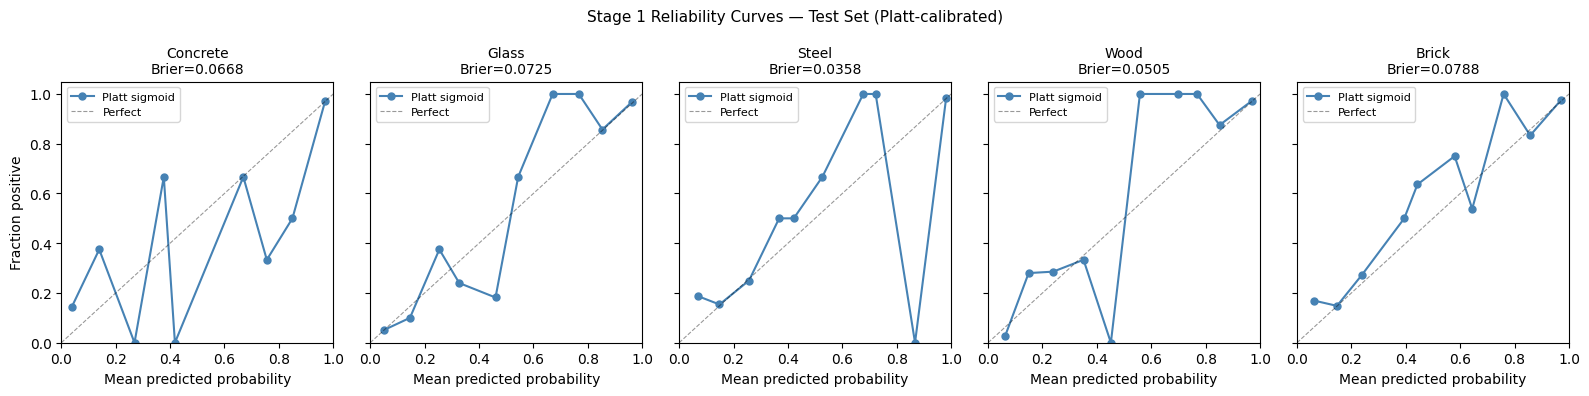

In [11]:
# ==========================================================
# Stage 1 — Reliability diagnostics (Platt-calibrated)
# ==========================================================
# CalibratedClassifierCV(method='sigmoid') is applied during fit(),
# so no separate calibration step is needed.  This cell evaluates
# the resulting reliability on the test set.

y_val_presence  = data["y_val_mask"]  & (data["y_val_raw"]  > 0)
y_test_presence = data["y_test_mask"] & (data["y_test_raw"] > 0)

print("=" * 60)
print("Stage 1 reliability — TEST SET  (Platt-calibrated)")
print("=" * 60)
cal_result = model.stage1.evaluate_calibration(data["X_test_proc"], y_test_presence)

# ── Reliability curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(y_cols), figsize=(16, 4), sharey=True)
for ax, mat in zip(axes, y_cols):
    res = cal_result.get(mat, {})
    mp  = res.get("mean_pred_bins")
    fp  = res.get("frac_pos_bins")
    if mp is not None and len(mp):
        ax.plot(mp, fp, "o-", color="steelblue", lw=1.5, ms=5, label="Platt sigmoid")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.4, label="Perfect")
    brier = res.get("brier", float("nan"))
    ax.set_title(f"{mat}\nBrier={brier:.4f}", fontsize=10)
    ax.set_xlabel("Mean predicted probability")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.05)
    ax.legend(fontsize=8)
    if ax is axes[0]:
        ax.set_ylabel("Fraction positive")

fig.suptitle(
    "Stage 1 Reliability Curves — Test Set (Platt-calibrated)",
    fontsize=11,
)
plt.tight_layout()
plt.show()


Concrete — calibration comparison  (evaluated on test set)
  True prevalence  val: 0.732   test: 0.769

  Method                                  Brier    LogLoss    MeanPred
  -------------------------------------------------------------------
  Platt sigmoid (model output)           0.0668     0.2419       0.753
  + Isotonic on top (val-fit)            0.0620     0.2343       0.756
  + Sigmoid on top (val-fit)             0.0668     0.2461       0.757

Bin sparsity — Platt-calibrated predictions for Concrete (val set)
  (n_val = 385, n_bins = 10)
       Bin range   n_samples    frac_pos        note
  ----------------------------------------------------
  [0.0, 0.1)          88       0.170            
  [0.1, 0.2)           9       0.444      SPARSE
  [0.2, 0.3)           0           —       empty
  [0.3, 0.4)           4       0.250      SPARSE
  [0.4, 0.5)           1       0.000      SPARSE
  [0.5, 0.6)           0           —       empty
  [0.6, 0.7)           1       0.000      S

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2851: FutureWarning: Setting the eps parameter is deprecated and will be removed in 1.5. Instead eps will always havea default value of `np.finfo(y_pred.dtype).eps`.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2851: FutureWarning: Setting the eps parameter is deprecated and will be removed in 1.5. Instead eps will always havea default value of `np.finfo(y_pred.dtype).eps`.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2851: FutureWarning: Setting the eps parameter is deprecated and will be removed in 1.5. Instead eps will always havea default value of `np.finfo(y_pred.dtype).eps`.
  warnings.warn(


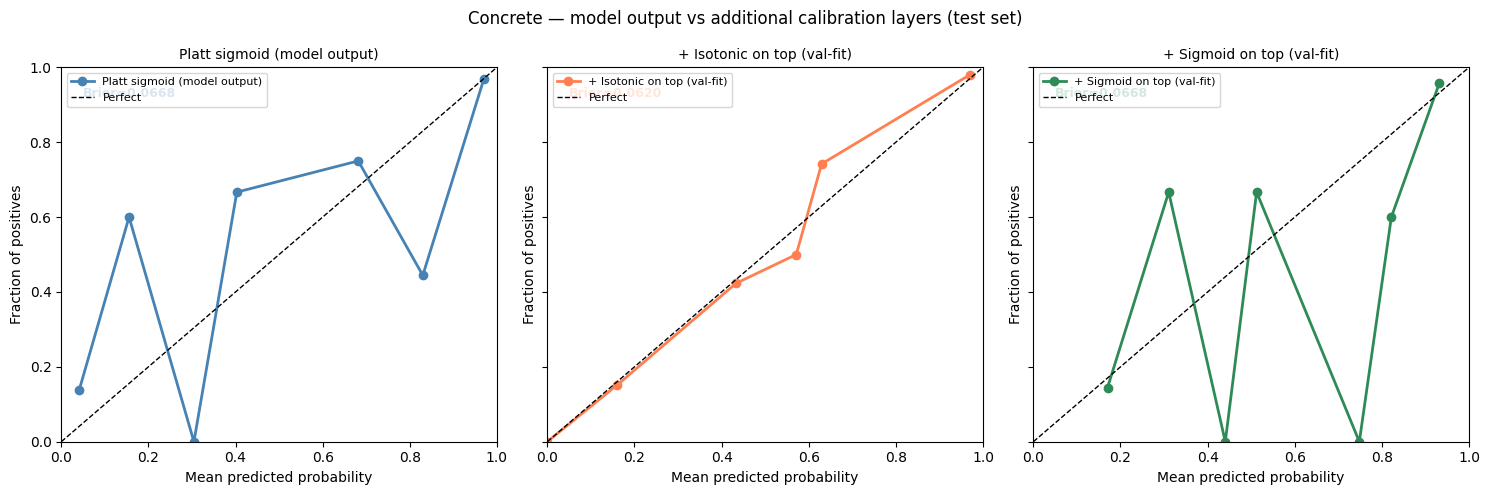

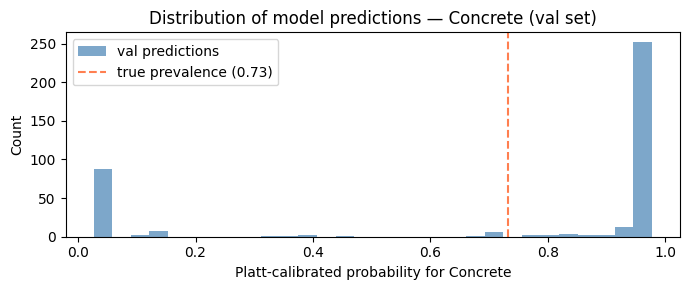

In [12]:
# ==========================================================
# Concrete calibration investigation
# ==========================================================
# Evaluates Platt-calibrated model output for Concrete and checks
# whether an additional isotonic layer on top would improve things,
# plus bin-level sparsity to justify the sigmoid choice.
# ==========================================================
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss

concrete_idx = y_cols.index("Concrete")

y_val_presence  = data["y_val_mask"]  & (data["y_val_raw"]  > 0)
y_test_presence = data["y_test_mask"] & (data["y_test_raw"] > 0)
y_true_val  = y_val_presence[:, concrete_idx].astype(float)
y_true_test = y_test_presence[:, concrete_idx].astype(float)

# ── 1. Current Platt-calibrated output from model ───────────────────────────
p_platt_val  = model.stage1.predict_proba(data["X_val_proc"])[:, concrete_idx]
p_platt_test = model.stage1.predict_proba(data["X_test_proc"])[:, concrete_idx]

# ── 2. Additional isotonic layer on top (val-fit → test-eval) ───────────────
iso_extra = IsotonicRegression(out_of_bounds="clip")
iso_extra.fit(p_platt_val, y_true_val)
p_iso_test = iso_extra.predict(p_platt_test)

# ── 3. Additional sigmoid layer on top (val-fit → test-eval) ────────────────
platt_extra = LogisticRegression(C=1e10, solver="lbfgs")
platt_extra.fit(p_platt_val.reshape(-1, 1), y_true_val.astype(int))
p_platt2_test = platt_extra.predict_proba(p_platt_test.reshape(-1, 1))[:, 1]

# ── 4. Metric table ──────────────────────────────────────────────────────────
print("=" * 65)
print("Concrete — calibration comparison  (evaluated on test set)")
print("=" * 65)
print(f"  True prevalence  val: {y_true_val.mean():.3f}   test: {y_true_test.mean():.3f}")
print()
print(f"  {'Method':<35}  {'Brier':>8}  {'LogLoss':>9}  {'MeanPred':>10}")
print("  " + "-" * 67)
for name, p in [
    ("Platt sigmoid (model output)",     p_platt_test),
    ("+ Isotonic on top (val-fit)",      p_iso_test),
    ("+ Sigmoid on top (val-fit)",       p_platt2_test),
]:
    bs = brier_score_loss(y_true_test, p)
    ll = log_loss(y_true_test, p, eps=1e-7)
    print(f"  {name:<35}  {bs:>8.4f}  {ll:>9.4f}  {p.mean():>10.3f}")

# ── 5. Bin sparsity (current Platt output, val set) ─────────────────────────
print()
print("=" * 65)
print("Bin sparsity — Platt-calibrated predictions for Concrete (val set)")
print(f"  (n_val = {len(p_platt_val)}, n_bins = 10)")
print("=" * 65)
print(f"  {'Bin range':>14}  {'n_samples':>10}  {'frac_pos':>10}  {'note':>10}")
print("  " + "-" * 52)
bins = np.linspace(0.0, 1.0, 11)
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (p_platt_val >= lo) & (p_platt_val < hi)
    cnt  = int(mask.sum())
    fp   = float(y_true_val[mask].mean()) if cnt > 0 else float("nan")
    note = "SPARSE" if (0 < cnt < 15) else ("empty" if cnt == 0 else "")
    fp_s = f"{fp:.3f}" if cnt > 0 else "—"
    print(f"  [{lo:.1f}, {hi:.1f})  {cnt:>10d}  {fp_s:>10}  {note:>10}")

print()
print(f"  Platt prediction range: [{p_platt_val.min():.3f}, {p_platt_val.max():.3f}]")
print(f"  Platt prediction std  : {p_platt_val.std():.4f}")

# ── 6. Reliability plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
configs = [
    ("Platt sigmoid (model output)",   p_platt_test,  "steelblue"),
    ("+ Isotonic on top (val-fit)",    p_iso_test,    "coral"),
    ("+ Sigmoid on top (val-fit)",     p_platt2_test, "seagreen"),
]
for ax, (label, p_plot, color) in zip(axes, configs):
    try:
        frac_pos, mean_pred = calibration_curve(y_true_test, p_plot, n_bins=8)
        ax.plot(mean_pred, frac_pos, "o-", color=color, lw=2, label=label)
    except ValueError:
        ax.text(0.5, 0.5, "too few bins", ha="center", va="center")
    ax.plot([0, 1], [0, 1], "--k", lw=1, label="Perfect")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
    bs = brier_score_loss(y_true_test, p_plot)
    ax.text(0.05, 0.92, f"Brier={bs:.4f}", transform=ax.transAxes,
            fontsize=9, color=color, fontweight="bold")

fig.suptitle("Concrete — model output vs additional calibration layers (test set)", fontsize=12)
plt.tight_layout()
plt.show()

# ── 7. Prediction distribution histogram ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(p_platt_val, bins=30, color="steelblue", alpha=0.7, label="val predictions")
ax.axvline(y_true_val.mean(), color="coral", linestyle="--",
           label=f"true prevalence ({y_true_val.mean():.2f})")
ax.set_xlabel("Platt-calibrated probability for Concrete")
ax.set_ylabel("Count")
ax.set_title("Distribution of model predictions — Concrete (val set)")
ax.legend()
plt.tight_layout()
plt.show()


In [13]:
# ===========================================================
# Stage 2 Quantile Spread Diagnostics
#
# For each material shows statistics of the quantile XGB
# predictions on held-out presence rows:
#   p50      — median prediction (kg/m²)
#   IW       — mean interval width p95 − p05 (kg/m²)
#   Data rng — observed max − min (sharpness reference)
#   σ_log    — log-space sigma inferred from p05/p95 spread
#              used in sample_query() for N(μ, σ²) draws
# ===========================================================

def show_quantile_spread(X, y_raw):
    print(f"{'Material':<12}  {'n_obs':>6}  {'Mean p50':>9}  "
          f"{'Mean IW':>9}  {'Data rng':>10}  {'Mean σ_log':>10}")
    print("-" * 67)
    for m, mat in enumerate(y_cols):
        qxgb = model.stage2.models_.get(mat)
        if qxgb is None:
            print(f"{mat:<12}  {'—':>6}  no model")
            continue
        obs = (~np.isnan(y_raw[:, m])) & (y_raw[:, m] > 0)
        if obs.sum() < 2:
            print(f"{mat:<12}  {'—':>6}  too few rows")
            continue
        pq        = qxgb.predict_q_log(X[obs])       # (n, 3) log-space
        p05       = np.maximum(np.exp(pq[:, 0]) - 1e-6, 0.0)
        p50       = np.maximum(np.exp(pq[:, 1]) - 1e-6, 0.0)
        p95       = np.maximum(np.exp(pq[:, 2]) - 1e-6, 0.0)
        iw        = float((p95 - p05).mean())
        drange    = float(y_raw[obs, m].max() - y_raw[obs, m].min())
        sigma_log = float(((pq[:, 2] - pq[:, 0]) / (2 * 1.6449)).mean())
        print(f"{mat:<12}  {int(obs.sum()):>6}  {p50.mean():>9.1f}  "
              f"{iw:>9.1f}  {drange:>10.1f}  {sigma_log:>10.4f}")

print("=" * 67)
print("Stage 2 Quantile Spread — VALIDATION SET")
print("=" * 67)
show_quantile_spread(data["X_val_proc"], data["y_val_raw"])

print()
print("=" * 67)
print("Stage 2 Quantile Spread — TEST SET")
print("=" * 67)
show_quantile_spread(data["X_test_proc"], data["y_test_raw"])


Stage 2 Quantile Spread — VALIDATION SET
Material       n_obs   Mean p50    Mean IW    Data rng  Mean σ_log
-------------------------------------------------------------------
Concrete         282     1252.9     2033.2      4489.8      0.5513
Glass            176        2.7        4.5        13.2      0.4861
Steel            344       40.0       91.1       426.9      0.6885
Wood             316       21.4       43.7       162.0      0.9676
Brick            257      562.5      893.9      2153.5      0.6522

Stage 2 Quantile Spread — TEST SET
Material       n_obs   Mean p50    Mean IW    Data rng  Mean σ_log
-------------------------------------------------------------------
Concrete         297     1301.1     2090.8      4471.5      0.5416
Glass            193        2.7        4.4        15.0      0.4899
Steel            346       36.3       85.4       427.2      0.6983
Wood             313       17.4       41.8       162.0      0.9771
Brick            277      598.3      894.8      21

In [14]:
# ===========================================================
# Stage 2 Point Estimate Accuracy  (MAE, RMSE, R²)
#
# Evaluates the p50 (median) prediction against true observed
# intensities on presence rows only (presence = observed AND > 0).
# ===========================================================

def show_point_accuracy(X, y_raw):
    print(f"{'Material':<12}  {'n_obs':>6}  {'MAE':>9}  {'RMSE':>9}  {'R²':>7}")
    print("-" * 52)
    for m, mat in enumerate(y_cols):
        qxgb = model.stage2.models_.get(mat)
        if qxgb is None:
            print(f"{mat:<12}  {'—':>6}  no model")
            continue
        obs = (~np.isnan(y_raw[:, m])) & (y_raw[:, m] > 0)
        if obs.sum() < 2:
            print(f"{mat:<12}  {'—':>6}  too few rows")
            continue
        y_obs  = y_raw[obs, m]
        pq     = qxgb.predict_q_log(X[obs])           # (n, 3) log-space
        p50    = np.maximum(np.exp(pq[:, 1]) - 1e-6, 0.0)
        mae    = float(np.mean(np.abs(p50 - y_obs)))
        rmse   = float(np.sqrt(np.mean((p50 - y_obs) ** 2)))
        ss_res = float(np.sum((y_obs - p50) ** 2))
        ss_tot = float(np.sum((y_obs - y_obs.mean()) ** 2))
        r2     = 1.0 - ss_res / (ss_tot + 1e-9)
        print(f"{mat:<12}  {int(obs.sum()):>6}  {mae:>9.2f}  {rmse:>9.2f}  {r2:>7.3f}")

print("=" * 52)
print("Point Estimate Accuracy — VALIDATION SET")
print("=" * 52)
show_point_accuracy(data["X_val_proc"], data["y_val_raw"])

print()
print("=" * 52)
print("Point Estimate Accuracy — TEST SET")
print("=" * 52)
show_point_accuracy(data["X_test_proc"], data["y_test_raw"])


Point Estimate Accuracy — VALIDATION SET
Material       n_obs        MAE       RMSE       R²
----------------------------------------------------
Concrete         282     405.27     600.64    0.443
Glass            176       1.23       1.82    0.278
Steel            344      21.61      51.74    0.241
Wood             316      10.42      21.34    0.619
Brick            257     212.02     308.10    0.351

Point Estimate Accuracy — TEST SET
Material       n_obs        MAE       RMSE       R²
----------------------------------------------------
Concrete         297     478.19     739.33    0.270
Glass            193       1.12       1.75    0.377
Steel            346      19.14      45.98    0.283
Wood             313       9.31      18.64    0.568
Brick            277     205.08     286.85    0.441


In [15]:
# ==========================================================
# CRPS (Continuous Ranked Probability Score) — probabilistic calibration
# ==========================================================

print("=" * 60)
print("CRPS evaluation — VALIDATION SET")
print("=" * 60)
model.stage2.evaluate_crps(data["X_val_proc"], data["y_val_raw"])

print()
print("=" * 60)
print("CRPS evaluation — TEST SET")
print("=" * 60)
model.stage2.evaluate_crps(data["X_test_proc"], data["y_test_raw"])

CRPS evaluation — VALIDATION SET
  Material       n_obs   Mean CRPS (log-space)
  --------------------------------------------
  Concrete         282                  0.3188
  Glass            176                  0.3212
  Steel            344                  0.3680
  Wood             316                  0.5242
  Brick            257                  0.4386

CRPS evaluation — TEST SET
  Material       n_obs   Mean CRPS (log-space)
  --------------------------------------------
  Concrete         297                  0.3602
  Glass            193                  0.3158
  Steel            346                  0.3654
  Wood             313                  0.4854
  Brick            277                  0.3362


Calibration — VALIDATION SET
  Material       n_obs     10%   20%   30%   40%   50%   60%   70%   80%   90%
  -------------------------------------------------------------------------------------
  Concrete         282    0.13  0.29  0.38  0.54  0.63  0.71  0.77  0.84  0.87
  Glass            176    0.08  0.18  0.30  0.40  0.53  0.59  0.66  0.78  0.88
  Steel            344    0.15  0.29  0.41  0.52  0.60  0.69  0.79  0.85  0.90
  Wood             316    0.17  0.31  0.44  0.53  0.64  0.73  0.79  0.84  0.90
  Brick            257    0.14  0.25  0.39  0.49  0.59  0.67  0.75  0.81  0.89

Calibration — TEST SET
  Material       n_obs     10%   20%   30%   40%   50%   60%   70%   80%   90%
  -------------------------------------------------------------------------------------
  Concrete         297    0.13  0.27  0.39  0.49  0.57  0.68  0.74  0.82  0.87
  Glass            193    0.11  0.23  0.36  0.46  0.56  0.64  0.74  0.82  0.89
  Steel            346    0.12  0.28  0.40  0.51  0.64  0.72

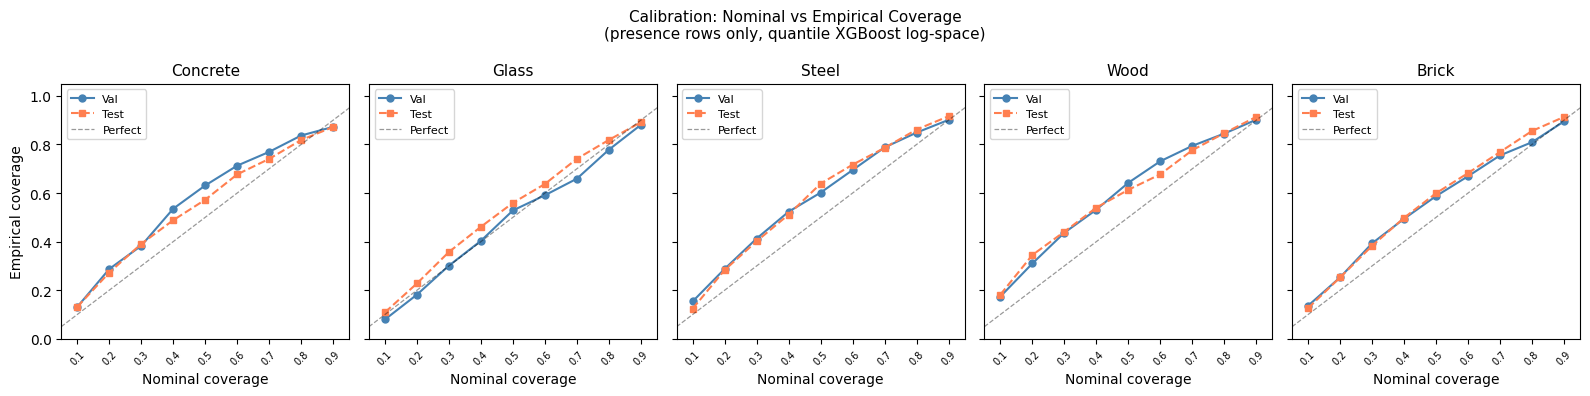

In [16]:
# ==========================================================
# Calibration — nominal vs empirical coverage (presence rows)
# ==========================================================

levels = np.linspace(0.10, 0.90, 9)

print("Calibration — VALIDATION SET")
cal_val  = model.stage2.evaluate_calibration(data["X_val_proc"],  data["y_val_raw"],  levels=levels)
print()
print("Calibration — TEST SET")
cal_test = model.stage2.evaluate_calibration(data["X_test_proc"], data["y_test_raw"], levels=levels)

fig, axes = plt.subplots(1, len(y_cols), figsize=(16, 4), sharey=True)
for ax, material in zip(axes, y_cols):
    emp_v = cal_val.get(material)
    emp_t = cal_test.get(material)
    if emp_v is not None:
        ax.plot(levels, emp_v, "o-",  color="steelblue", lw=1.5, ms=5, label="Val")
    if emp_t is not None:
        ax.plot(levels, emp_t, "s--", color="coral",     lw=1.5, ms=5, label="Test")
    ax.plot([0, 1], [0, 1], "k--", lw=0.9, alpha=0.4, label="Perfect")
    ax.set_title(material, fontsize=11)
    ax.set_xlabel("Nominal coverage")
    ax.set_xlim(0.05, 0.95)
    ax.set_ylim(0.0, 1.05)
    ax.set_xticks(levels)
    ax.tick_params(axis="x", labelsize=7, rotation=45)
    ax.legend(fontsize=8)
    if ax is axes[0]:
        ax.set_ylabel("Empirical coverage")

fig.suptitle(
    "Calibration: Nominal vs Empirical Coverage\n(presence rows only, quantile XGBoost log-space)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

In [17]:
# ==========================================================
# Sampling realism diagnostics
# ==========================================================
# Evaluates 3 representative val rows: presence freq, co-occurrence,
# intensity distributions, diversity, and comparison to real buildings.

n_query   = 3
X_query   = data["X_val_proc"][:n_query]
grp_query = data["groups_val"][:n_query]

model.evaluate_sampling_realism(
    X_query, grp_query,
    y_train_raw  = data["y_train_raw"],
    y_train_mask = data["y_train_mask"],
    X_train_raw  = data["X_train_raw"],
    n_samples    = 1000,
    random_state = SEED,
)


Query row 0  |  group: B  |  n_samples=1000

A. Presence frequency per material:
   Concrete      0.880  |##################  |
   Glass         0.859  |#################   |
   Steel         0.883  |##################  |
   Wood          0.852  |#################   |
   Brick         0.878  |##################  |

B. Co-occurrence matrix  (fraction of samples):
             Concr  Glass  Steel   Wood  Brick
  Concrete      0.88  0.76  0.78  0.75  0.77
  Glass         0.76  0.86  0.76  0.73  0.76
  Steel         0.78  0.76  0.88  0.75  0.78
  Wood          0.75  0.73  0.75  0.85  0.75
  Brick         0.77  0.76  0.78  0.75  0.88

C. Sampled intensity distribution  (kg/m², presence rows only):
   Material      n_pres      mean    median        p5       p95
   ----------------------------------------------------------
   Concrete         880    1807.3    1588.9     693.8    3787.3
   Glass            859       3.0       2.4       0.8       7.0
   Steel            883      20.6      16.3

In [18]:
# ==========================================================
# Automatic Hyperparameter Tuning Workflow (Optuna)
# ==========================================================
def compute_naive_maes(y_train_raw, y_train_mask):
    # MAE of per-material training-mean naive forecast — denominator for MASE.
    # Presence rows only: the conditional regressor is trained on y > 0,
    # so the naive baseline must be computed on the same support.
    naive_maes = {}
    for m, mat in enumerate(y_cols):
        obs = y_train_mask[:, m] & (y_train_raw[:, m] > 0)
        if obs.sum() > 0:
            vals = y_train_raw[obs, m]
            naive_maes[mat] = float(np.mean(np.abs(vals - vals.mean())))
    return naive_maes


def compute_mase(pred_dict, y_df, naive_maes, eps=1e-8):
    # MASE averaged across materials, evaluated on presence rows only.
    # Evaluating Stage 2 (conditional intensity) against y=0 rows would
    # penalise it for a job that belongs to Stage 1 (presence classification).
    mases = []
    for mat in y_cols:
        y_true = y_df[mat].to_numpy(dtype=float)
        obs = (~np.isnan(y_true)) & (y_true > 0)
        if np.any(obs):
            y_pred = pred_dict[mat]["p50"][obs]
            mae = np.mean(np.abs(y_pred - y_true[obs]))
            mases.append(mae / (naive_maes.get(mat, 1.0) + eps))
    return float(np.mean(mases)) if mases else np.inf


naive_maes = compute_naive_maes(data["y_train_raw"], data["y_train_mask"])

import io, contextlib
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    n_estimators     = trial.suggest_int("n_estimators", 100, 600)
    max_depth        = trial.suggest_int("max_depth", 3, 7)
    learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    subsample        = trial.suggest_float("subsample", 0.6, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)
    reg_alpha        = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True)
    reg_lambda       = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True)
    cov_shrink       = trial.suggest_float("cov_shrink", 0.0, 1.0)
    min_group_size   = trial.suggest_int("min_group_size", 10, 40)
    reg_eps          = trial.suggest_float("reg_eps", 1e-6, 1e-2, log=True)

    tuned_model = TwoStageConditionalModel(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        cov_shrink=cov_shrink,
        min_group_size=min_group_size,
        reg_eps=reg_eps,
        random_state=SEED,
    )
    with contextlib.redirect_stdout(io.StringIO()):
        tuned_model.fit(
            data["X_train_proc"],
            data["X_train_raw"],
            data["y_train_raw"],
            data["y_train_mask"],
        )
    preds_val = tuned_model.predict(data["X_val_proc"], data["groups_val"], alpha=0.10)
    return compute_mase(preds_val, data["y_val_df"], naive_maes)

set_global_seed(SEED)
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
def _cb(study, trial):
    if trial.number % 10 == 9 or trial.number == 0:
        print(f"  trial {trial.number+1:3d}/50  best MASE={study.best_value:.4f}")

study.optimize(objective, n_trials=50, show_progress_bar=False, callbacks=[_cb])

print("Best validation MASE:", round(study.best_value, 6))
print("Best params:", study.best_params)

best = study.best_params
model = TwoStageConditionalModel(
    n_estimators=best["n_estimators"],
    max_depth=best["max_depth"],
    learning_rate=best["learning_rate"],
    subsample=best["subsample"],
    colsample_bytree=best["colsample_bytree"],
    reg_alpha=best["reg_alpha"],
    reg_lambda=best["reg_lambda"],
    cov_shrink=best["cov_shrink"],
    min_group_size=best["min_group_size"],
    reg_eps=best["reg_eps"],
    random_state=SEED,
)
with contextlib.redirect_stdout(io.StringIO()):
    model.fit(
        data["X_train_proc"],
        data["X_train_raw"],
        data["y_train_raw"],
        data["y_train_mask"],
    )
print("Tuned model fitted  |  groups retained:", sorted(model.joint.group_covs_.keys()))

# Re-fit post-hoc sampling calibration on the tuned model
y_val_presence = data["y_val_mask"] & (data["y_val_raw"] > 0)
model.calibrate_sampling(
    data["X_val_proc"], y_val_presence,
    n_samples=2000, temperature=2.5, random_state=SEED,
)
print("Joint sampling calibration re-fitted on tuned model.")

  trial   1/50  best MASE=0.6378
  trial  10/50  best MASE=0.6296
  trial  20/50  best MASE=0.6260
  trial  30/50  best MASE=0.6249
  trial  40/50  best MASE=0.6249
  trial  50/50  best MASE=0.6240
Best validation MASE: 0.624003
Best params: {'n_estimators': 119, 'max_depth': 7, 'learning_rate': 0.08549427615942543, 'subsample': 0.9746109233213803, 'colsample_bytree': 0.6885715333668371, 'reg_alpha': 0.001555351458336401, 'reg_lambda': 0.000907549783015129, 'cov_shrink': 0.4628700295878825, 'min_group_size': 31, 'reg_eps': 1.5406590706306678e-06}
Tuned model fitted  |  groups retained: ['B', 'C', 'S', 'W']
Joint sampling calibration re-fitted on tuned model.


In [19]:
# ==========================================================
# Prediction on test set
# ==========================================================

pred_test = model.predict(data["X_test_proc"], data["groups_test"], alpha=0.10)

print("Sample predictions (first 3 test buildings):\n")
for mat in y_cols:
    p = pred_test[mat]
    print(
        f"{mat:<10s}  "
        f"p_presence={np.round(p['p_presence'][:3], 2)}  "
        f"p50={np.round(p['p50'][:3], 1)}  "
        f"90%PI=[{np.round(p['p5'][:3], 1)}, {np.round(p['p95'][:3], 1)}]"
    )


Sample predictions (first 3 test buildings):

Concrete    p_presence=[0.03 0.97 0.89]  p50=[1217.2 1464.3  814.8]  90%PI=[[368.4 825.6 346.5], [4021.7 2597.3 1915.9]]
Glass       p_presence=[0.96 0.96 0.33]  p50=[2.9 1.7 1.6]  90%PI=[[1.2 0.9 0.9], [7.  3.2 3. ]]
Steel       p_presence=[0.98 0.98 0.95]  p50=[23.3 23.1 13.4]  90%PI=[[8.2 7.5 5.7], [66.4 71.4 31.9]]
Wood        p_presence=[0.97 0.97 0.97]  p50=[20.5 10.7  0.3]  90%PI=[[3.1 1.8 0.1], [137.8  62.7   1. ]]
Brick       p_presence=[0.97 0.96 0.97]  p50=[135.1 132.7 325.1]  90%PI=[[ 41.1  24.9 165. ], [444.3 708.4 640.4]]


Model Assessment

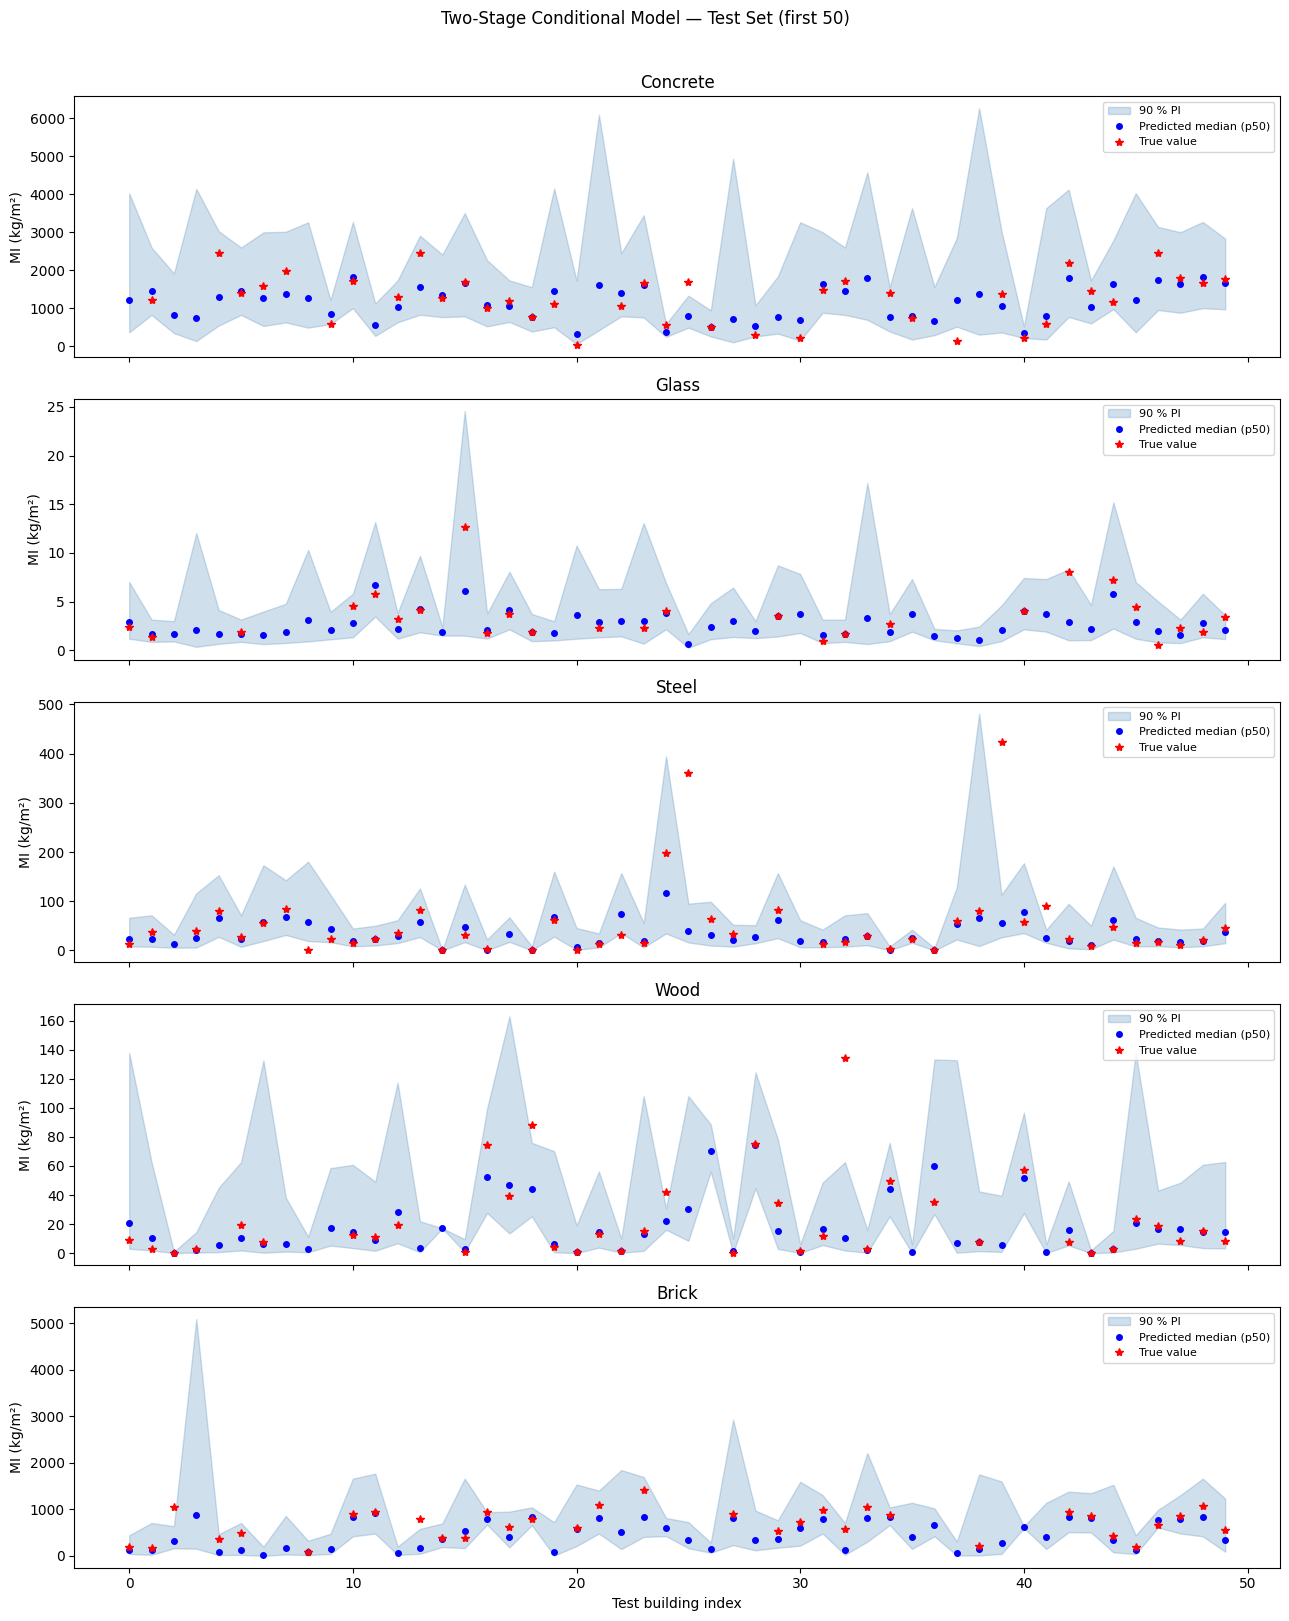

In [20]:
# ==========================================================
# Visualisation — predicted median + 90 % PI vs. true values
#                 (first 50 test-set buildings)
# ==========================================================

n_plot = 50
pred_plot = model.predict(data["X_test_proc"][:n_plot], data["groups_test"][:n_plot], alpha=0.10)

fig, axes = plt.subplots(5, 1, figsize=(13, 16), sharex=True)
x_idx = np.arange(n_plot)

for i, mat in enumerate(y_cols):
    ax = axes[i]
    y_true = data["y_test_df"][mat].iloc[:n_plot].to_numpy(dtype=float)
    observed = ~np.isnan(y_true)
    y_true_plot = y_true.copy()
    y_true_plot[~observed] = np.nan

    ax.fill_between(x_idx, pred_plot[mat]["p5"], pred_plot[mat]["p95"],
                    alpha=0.25, color="steelblue", label="90 % PI")
    ax.plot(x_idx, pred_plot[mat]["p50"], "bo", ms=4, label="Predicted median (p50)")
    ax.plot(x_idx, y_true_plot, "r*", ms=6, label="True value")
    ax.set_title(mat)
    ax.set_ylabel("MI (kg/m\u00b2)")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Test building index")
plt.suptitle("Two-Stage Conditional Model \u2014 Test Set (first 50)", y=1.01)
plt.tight_layout()
plt.show()


Presence-complete test rows: 135
  mean_vector_mae: 36.207
  cov_frobenius: 2.4799e+05
  corr_frobenius: 1.264
  kl_true_to_pred: 24.917
  kl_pred_to_true: 2.6218


,material,true_mean,pred_mean,abs_mean_diff,true_std,pred_std,abs_std_diff
0,Concrete,1654.170734,1536.591366,117.579368,636.373380,402.488096,233.885284
1,Glass,2.922884,2.619600,0.303284,2.349873,1.184347,1.165526
2,Steel,25.643327,22.732407,2.910920,38.475675,14.340069,24.135606
3,Wood,23.603882,19.281359,4.322523,23.055424,13.772353,9.283071
4,Brick,682.684163,626.764939,55.919225,300.128005,250.448730,49.679276


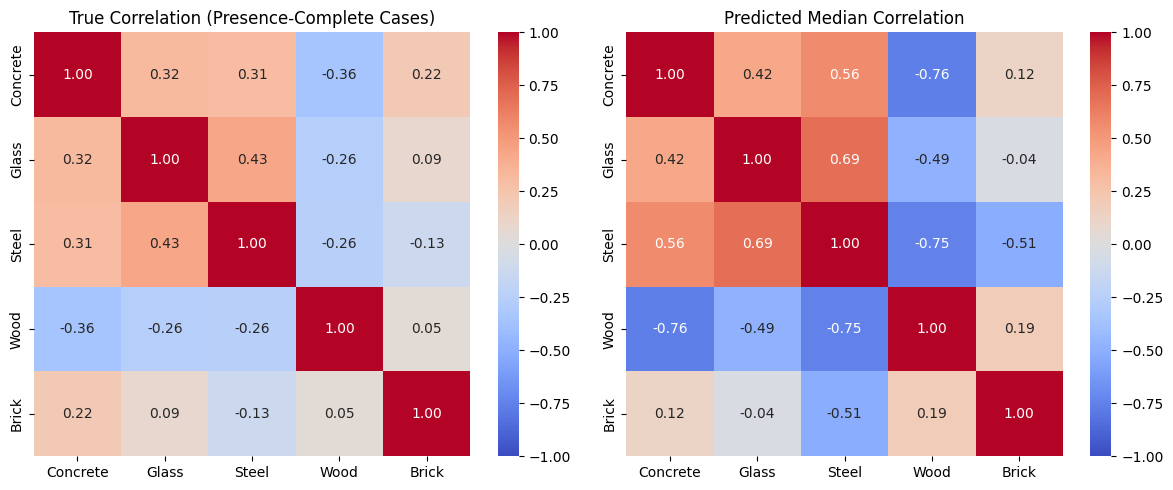

In [21]:
# ==========================================================
# Joint distribution evaluation
#   - Marginal moments (presence-complete rows)
#   - Material correlation heatmaps (true vs. predicted)
# ==========================================================

def _gaussian_kl(mu_p, cov_p, mu_q, cov_q, eps=1e-6):
    d = mu_p.shape[0]
    cov_p_r = cov_p + np.eye(d) * eps
    cov_q_r = cov_q + np.eye(d) * eps
    sp, ldp = np.linalg.slogdet(cov_p_r)
    sq, ldq = np.linalg.slogdet(cov_q_r)
    if sp <= 0 or sq <= 0:
        return np.nan
    inv_q = np.linalg.inv(cov_q_r)
    return 0.5 * (np.trace(inv_q @ cov_p_r)
                  + (mu_q - mu_p) @ inv_q @ (mu_q - mu_p)
                  - d + (ldq - ldp))


# Presence-complete rows: all 5 materials observed AND > 0.
# Matches the support used by JointDistributionModel.fit(); using y_mask.all()
# would include observed-as-zero rows whose covariance is not well-defined.
cc = (~np.isnan(data["y_test_raw"]) & (data["y_test_raw"] > 0)).all(axis=1)
y_tc = data["y_test_raw"][cc]
y_pc = model.stage2.predict(data["X_test_proc"][cc])

mu_t, mu_p   = y_tc.mean(0), y_pc.mean(0)
std_t, std_p = y_tc.std(0, ddof=1), y_pc.std(0, ddof=1)
cov_t  = np.cov(y_tc, rowvar=False)
cov_p  = np.cov(y_pc, rowvar=False)
corr_t = np.corrcoef(y_tc, rowvar=False)
corr_p = np.corrcoef(y_pc, rowvar=False)

print(f"Presence-complete test rows: {cc.sum()}")
stats_summary = {
    "mean_vector_mae":  float(np.mean(np.abs(mu_t - mu_p))),
    "cov_frobenius":    float(np.linalg.norm(cov_t - cov_p, ord="fro")),
    "corr_frobenius":   float(np.linalg.norm(corr_t - corr_p, ord="fro")),
    "kl_true_to_pred":  float(_gaussian_kl(mu_t, cov_t, mu_p, cov_p)),
    "kl_pred_to_true":  float(_gaussian_kl(mu_p, cov_p, mu_t, cov_t)),
}
for k, v in stats_summary.items():
    print(f"  {k}: {v:.5g}")

per_material = pd.DataFrame({
    "material": y_cols,
    "true_mean": mu_t, "pred_mean": mu_p, "abs_mean_diff": np.abs(mu_t - mu_p),
    "true_std":  std_t, "pred_std":  std_p, "abs_std_diff":  np.abs(std_t - std_p),
})
display(per_material)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, corr, title in zip(axes, [corr_t, corr_p],
                            ["True Correlation (Presence-Complete Cases)", "Predicted Median Correlation"]):
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                xticklabels=y_cols, yticklabels=y_cols, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()


In [22]:
# ==========================================================
# Save artefacts
# ==========================================================

# Rebind classes to the importable module path before pickling.
# This prevents __main__-scoped notebook classes from breaking joblib.load elsewhere.

model.__class__        = tsm.TwoStageConditionalModel
model.stage1.__class__ = tsm.MaterialOccurrenceModel
model.stage2.__class__ = tsm.MaterialIntensityModel
model.joint.__class__  = tsm.JointDistributionModel

for mat in y_cols:
    qxgb = model.stage2.models_.get(mat)
    if qxgb is not None:
        qxgb.__class__ = tsm._PerMaterialQuantileXGB

joblib.dump(data["preprocessor"], "preprocessor.joblib")
joblib.dump(model, "model.joblib")

model_info = {
    "model_type":  "TwoStageConditionalModel",
    "stage1":      "XGBClassifier per-material (binary:logistic, Platt-calibrated via CalibratedClassifierCV)",
    "stage2":      "XGBRegressor per-material quantile regression (reg:quantileerror, quantiles=[0.05,0.50,0.95], log-space)",
    "joint_layer": "MultivariateNormal with group-specific covariance (residual inspection only)",
    "group_cols":  list(GROUP_COLS),
    "y_cols":      y_cols,
    "X_cols":      X_cols,
    "stage1_xgb_params": model.stage1.xgb_params,
    "stage2_xgb_params": model.stage2.xgb_params,
}
with open("model_info.json", "w", encoding="utf-8") as f:
    json.dump(model_info, f, indent=2)

print("Saved: preprocessor.joblib,  model.joblib,  model_info.json")


Saved: preprocessor.joblib,  model.joblib,  model_info.json


In [23]:
# ==========================================================
# Validation 1 — Coverage, Interval Width, Median MAE
#   Evaluated on presence rows only (observed AND y > 0).
#   Coverage/MAE of the conditional intensity model against y=0 rows
#   is incoherent: those rows are Stage 1's responsibility.
# ==========================================================

coverage_results = []
for mat in y_cols:
    y_true = data["y_test_df"][mat].to_numpy(dtype=float)
    obs    = (~np.isnan(y_true)) & (y_true > 0)
    y_true = y_true[obs]
    q05 = pred_test[mat]["p5"][obs]
    q50 = pred_test[mat]["p50"][obs]
    q95 = pred_test[mat]["p95"][obs]
    widths = q95 - q05
    coverage_results.append({
        "material":     mat,
        "coverage_90":  round(float(np.mean((y_true >= q05) & (y_true <= q95))), 4),
        "mean_width":   round(float(widths.mean()), 2),
        "median_width": round(float(np.median(widths)), 2),
        "p50_mae":      round(mean_absolute_error(y_true, q50), 4),
    })

coverage_df = pd.DataFrame(coverage_results)
print("===== Coverage / Width / p50 MAE  (presence rows) =====")
print(coverage_df.to_string(index=False))


===== Coverage / Width / p50 MAE  (presence rows) =====
material  coverage_90  mean_width  median_width  p50_mae
Concrete       0.8721     2461.61       2183.65 477.5415
   Glass       0.8705        5.07          4.47   1.1390
   Steel       0.8902       84.59         64.38  18.9181
    Wood       0.8690       50.06         42.88   9.3321
   Brick       0.8773     1142.32        960.75 207.3808


In [24]:
# ==========================================================
# Validation 5 — Baseline Comparison (training-set median)
#   Both model MAE and baseline MAE restricted to presence rows,
#   matching the support of the conditional Stage 2 regressor.
# ==========================================================

baseline_results = []
for i, mat in enumerate(y_cols):
    tr = data["y_train_raw"][:, i]
    # Presence-only baseline: median of positive training values
    tr = tr[(~np.isnan(tr)) & (tr > 0)]
    train_median = float(np.median(tr)) if len(tr) > 0 else 0.0

    y_true = data["y_test_df"][mat].to_numpy(dtype=float)
    obs    = (~np.isnan(y_true)) & (y_true > 0)
    y_true = y_true[obs]

    b_mae = mean_absolute_error(y_true, np.full_like(y_true, train_median))
    m_mae = coverage_df.loc[coverage_df["material"] == mat, "p50_mae"].values[0]

    baseline_results.append({
        "Material":        mat,
        "Baseline MAE":    round(b_mae, 2),
        "Model MAE":       round(float(m_mae), 2),
        "Improvement (%)": round((b_mae - m_mae) / b_mae * 100, 1) if b_mae > 0 else float("nan"),
    })

print("===== Baseline Comparison  (presence rows) =====")
print(pd.DataFrame(baseline_results).to_string(index=False))


===== Baseline Comparison  (presence rows) =====
Material  Baseline MAE  Model MAE  Improvement (%)
Concrete        662.18     477.54             27.9
   Glass          1.42       1.14             19.8
   Steel         30.40      18.92             37.8
    Wood         17.62       9.33             47.0
   Brick        301.84     207.38             31.3


In [25]:
# ==========================================================
# Paper Validation — Task 1: Stronger Baseline Comparison
#   Trains RandomForestRegressor and Ridge on the same training
#   presence rows as Stage 2.  MAE evaluated on test presence rows
#   (y > 0) only — the conditional support of Stage 2.
# ==========================================================
import warnings
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

stronger_baseline_rows = []

for m, mat in enumerate(y_cols):
    # Presence rows in each split
    tr_pres = data["y_train_mask"][:, m] & (data["y_train_raw"][:, m] > 0)
    te_pres = data["y_test_mask"][:,  m] & (data["y_test_raw"][:,  m] > 0)

    if tr_pres.sum() < 10 or te_pres.sum() < 3:
        continue

    X_tr = data["X_train_proc"][tr_pres]
    y_tr = data["y_train_raw"][tr_pres, m]
    X_te = data["X_test_proc"][te_pres]
    y_te = data["y_test_raw"][te_pres, m]

    # ── Median baseline ───────────────────────────────────────────────────
    median_val = float(np.median(y_tr))
    mae_median = float(np.mean(np.abs(y_te - median_val)))

    # ── Ridge (linear, L2) ────────────────────────────────────────────────
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_tr, y_tr)
    mae_ridge = float(np.mean(np.abs(y_te - ridge.predict(X_te))))

    # ── Random Forest ─────────────────────────────────────────────────────
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        rf = RandomForestRegressor(
            n_estimators=300, max_depth=8,
            random_state=SEED, n_jobs=-1,
        )
        rf.fit(X_tr, y_tr)
    mae_rf = float(np.mean(np.abs(y_te - rf.predict(X_te))))

    # ── Stage 2 XGBoost (our model — p50) ────────────────────────────────
    qxgb = model.stage2.models_.get(mat)
    if qxgb is not None:
        p50_log = qxgb.predict_q_log(X_te)[:, 1]
        mae_model = float(np.mean(np.abs(y_te - (np.exp(p50_log) - LOG_EPS))))
    else:
        mae_model = float("nan")

    stronger_baseline_rows.append(dict(
        Material        = mat,
        n_test          = int(te_pres.sum()),
        MAE_Median      = round(mae_median, 2),
        MAE_Ridge       = round(mae_ridge,  2),
        MAE_RF          = round(mae_rf,     2),
        MAE_Stage2_p50  = round(mae_model,  2),
        vs_Median_pct   = round((mae_median - mae_model) / mae_median * 100, 1),
        vs_RF_pct       = round((mae_rf     - mae_model) / mae_rf     * 100, 1),
    ))

df_stronger = pd.DataFrame(stronger_baseline_rows)
print("=" * 80)
print("STRONGER BASELINE — Stage 2 MAE on test presence rows")
print("=" * 80)
print(df_stronger.to_string(index=False))
print()
print("Columns: MAE in kg/m².  vs_X_pct = % improvement of Stage 2 over X.")
print("Ridge: L2-regularised linear model (alpha=1.0), trained on presence rows.")
print("RF:    RandomForestRegressor(n_estimators=300, max_depth=8).")


STRONGER BASELINE — Stage 2 MAE on test presence rows
Material  n_test  MAE_Median  MAE_Ridge  MAE_RF  MAE_Stage2_p50  vs_Median_pct  vs_RF_pct
Concrete     297      662.18     605.30  486.70          477.54           27.9        1.9
   Glass     193        1.42       1.37    1.14            1.14           19.8        0.5
   Steel     346       30.40      25.34   20.65           18.92           37.8        8.4
    Wood     313       17.62      13.81   11.16            9.33           47.0       16.3
   Brick     277      301.84     219.26  218.19          207.38           31.3        5.0

Columns: MAE in kg/m².  vs_X_pct = % improvement of Stage 2 over X.
Ridge: L2-regularised linear model (alpha=1.0), trained on presence rows.
RF:    RandomForestRegressor(n_estimators=300, max_depth=8).


In [26]:
# ==========================================================
# Paper Validation — Task 2: Structural Prior Sensitivity
#   Tests STRUCTURAL_PRIOR floor values [0.0, 0.5, 0.7, 0.9].
#   Metric: presence frequency error |sampled_freq − true_freq|
#   for the dominant structural material within its building group.
#   Reported across-material Brier score (BCE) for Stage 1 outputs.
# ==========================================================
PRIOR_VALUES = [0.0, 0.5, 0.7, 0.9]
N_SENS       = 400          # samples per row; enough for stable freq estimates

y_test_pres = data["y_test_mask"] & (data["y_test_raw"] > 0)
groups_test = data["groups_test"]

# Structural code → (material name, material index)
struct_map = {
    "B": ("Brick",    y_cols.index("Brick")),
    "C": ("Concrete", y_cols.index("Concrete")),
    "S": ("Steel",    y_cols.index("Steel")),
    "W": ("Wood",     y_cols.index("Wood")),
}

# True structural presence rate within each group
true_struct_freq = {}
for code, (mat, midx) in struct_map.items():
    grp_mask = np.array([g == code for g in groups_test])
    if grp_mask.sum() > 0:
        true_struct_freq[code] = float(y_test_pres[grp_mask, midx].mean())

print("True structural presence frequencies by group:")
for code, freq in true_struct_freq.items():
    mat = struct_map[code][0]
    print(f"  Group {code} ({mat}): {freq:.3f}")
print()

sens_rows = []
for pval in PRIOR_VALUES:
    # Temporarily override STRUCTURAL_PRIOR in the notebook scope.
    # sample_presence() looks up STRUCTURAL_PRIOR at call time.
    orig = {k: v.copy() for k, v in STRUCTURAL_PRIOR.items()}
    STRUCTURAL_PRIOR.clear()
    if pval > 0:
        for code, (mat, _) in struct_map.items():
            STRUCTURAL_PRIOR[code] = {mat: pval}

    pres_samp = model.stage1.sample_presence(
        data["X_test_proc"],
        n_samples=N_SENS,
        temperature=2.5,
        random_state=SEED,
        primary_codes=groups_test,
    )  # (n_test, N_SENS, M)

    STRUCTURAL_PRIOR.clear()
    STRUCTURAL_PRIOR.update(orig)          # restore

    samp_freq = pres_samp.mean(axis=1)    # (n_test, M)

    row = {"Prior": pval}
    abs_errs = []
    for code, (mat, midx) in struct_map.items():
        grp_mask = np.array([g == code for g in groups_test])
        if grp_mask.sum() == 0:
            continue
        true_f = true_struct_freq.get(code, np.nan)
        samp_f = float(samp_freq[grp_mask, midx].mean())
        err = abs(true_f - samp_f)
        row[f"{code}({mat[:3]}) |err|"] = round(err, 3)
        abs_errs.append(err)

    # Overall Brier score: mean squared error on all test rows × all materials
    true_bin = y_test_pres.astype(float)                       # (n_test, M)
    pred_freq = samp_freq                                       # (n_test, M)
    brier = float(np.mean((pred_freq - true_bin) ** 2))
    row["Mean |err|"] = round(float(np.mean(abs_errs)), 3)
    row["Brier score"] = round(brier, 4)
    sens_rows.append(row)

df_sens = pd.DataFrame(sens_rows)
print("=" * 70)
print("STRUCTURAL PRIOR SENSITIVITY (n_samples=%d per row)" % N_SENS)
print("=" * 70)
print(df_sens.to_string(index=False))
print()
print("|err| = |sampled presence freq − true freq| within structural group.")
print("Brier = mean((sampled_freq − true_binary)²) across all test rows × materials.")
print("Lower is better for both metrics.")

best_mean_idx = df_sens["Mean |err|"].idxmin()
best_brier_idx = df_sens["Brier score"].idxmin()
print(f"\nBest prior by Mean |err|:   {df_sens.loc[best_mean_idx, 'Prior']}")
print(f"Best prior by Brier score:  {df_sens.loc[best_brier_idx, 'Prior']}")


True structural presence frequencies by group:
  Group B (Brick): 0.894
  Group C (Concrete): 0.856
  Group S (Steel): 1.000
  Group W (Wood): 1.000

STRUCTURAL PRIOR SENSITIVITY (n_samples=400 per row)
 Prior  B(Bri) |err|  C(Con) |err|  S(Ste) |err|  W(Woo) |err|  Mean |err|  Brier score
   0.0         0.051         0.029         0.136          0.13       0.087       0.0713
   0.5         0.051         0.029         0.136          0.13       0.087       0.0713
   0.7         0.051         0.029         0.136          0.13       0.087       0.0713
   0.9         0.051         0.029         0.136          0.13       0.087       0.0713

|err| = |sampled presence freq − true freq| within structural group.
Brier = mean((sampled_freq − true_binary)²) across all test rows × materials.
Lower is better for both metrics.

Best prior by Mean |err|:   0.0
Best prior by Brier score:  0.0


Material       n_obs   Shapiro-W     p-value   KS stat      KS p     Verdict
------------------------------------------------------------------------
  Concrete        1385      0.8659      0.0000    0.1085    0.0000  non-normal
  Glass            886      0.9209      0.0000    0.0770    0.0001  non-normal
  Steel           1638      0.9529      0.0000    0.0715    0.0000  non-normal
  Wood            1452      0.0098      0.0000    0.5090    0.0000  non-normal
  Brick           1200      0.0109      0.0000    0.5071    0.0000  non-normal


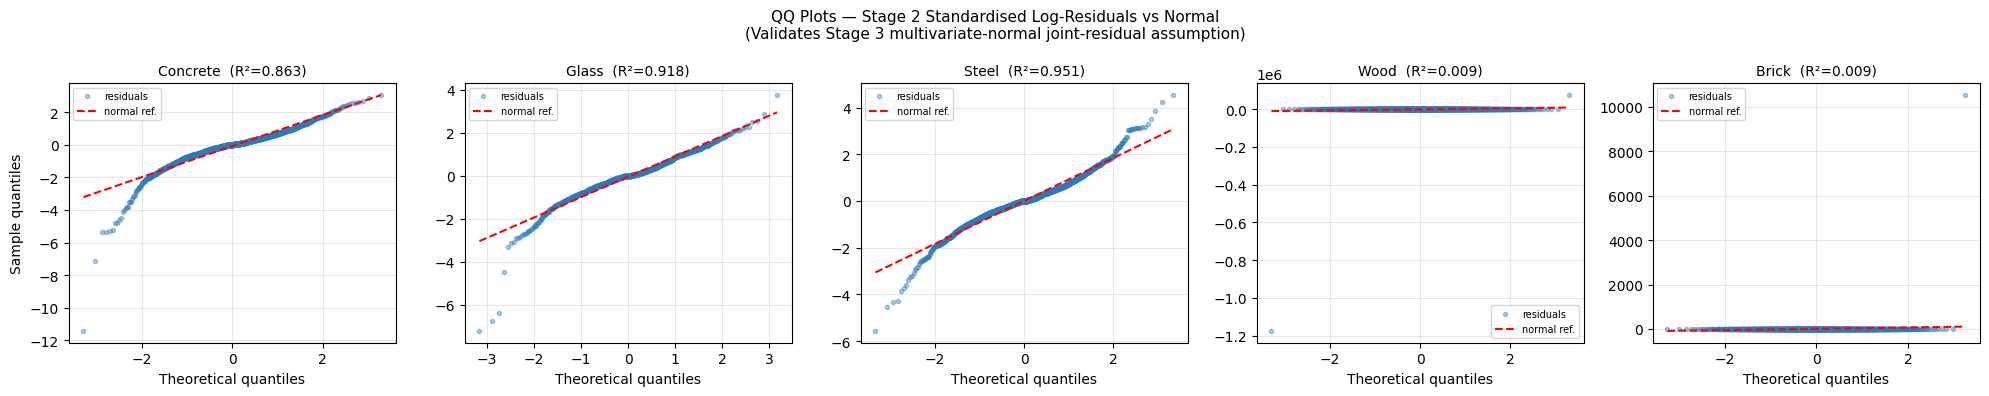


Saved: appendix_qq_plots.pdf


In [27]:
# ==========================================================
# Paper Validation — Task 3: Stage 3 Normality — QQ Plots
#   Computes standardised log-residuals from Stage 2 on training
#   presence rows.  QQ plots and Shapiro-Wilk / KS tests validate
#   the multivariate-normal assumption used in Stage 3 joint sampling.
# ==========================================================
from scipy.stats import probplot, shapiro, kstest, norm as scipy_norm

mu_log_train = model.stage2.predict_log(data["X_train_proc"])   # (n_train, M)

fig, axes = plt.subplots(1, len(y_cols), figsize=(4 * len(y_cols), 4), sharey=False)
fig.suptitle(
    "QQ Plots — Stage 2 Standardised Log-Residuals vs Normal\n"
    "(Validates Stage 3 multivariate-normal joint-residual assumption)",
    fontsize=11,
)

print(f"{'Material':<12}  {'n_obs':>6}  {'Shapiro-W':>10}  {'p-value':>10}  "
      f"{'KS stat':>8}  {'KS p':>8}  {'Verdict':>10}")
print("-" * 72)

for ax, (m, mat) in zip(axes, enumerate(y_cols)):
    obs = data["y_train_mask"][:, m] & (data["y_train_raw"][:, m] > 0)
    if obs.sum() < 8:
        ax.set_title(mat)
        ax.text(0.5, 0.5, "insufficient data", ha="center", transform=ax.transAxes)
        print(f"  {mat:<12}  {'—':>6}")
        continue

    y_log   = np.log(data["y_train_raw"][obs, m] + LOG_EPS)
    mu      = mu_log_train[obs, m]
    sigma   = model.stage2.models_[mat]._sigma(
                  model.stage2.models_[mat].predict_q_log(data["X_train_proc"][obs])
              )
    resid   = (y_log - mu) / np.maximum(sigma, 1e-8)    # standardised residuals

    # QQ plot
    (osm, osr), (slope, intercept, r) = probplot(resid, dist="norm", plot=None)
    ax.plot(osm, osr,  "o", ms=3, alpha=0.4, color="#2b7bba", label="residuals")
    ax.plot(osm, slope * osm + intercept, "r--", lw=1.5, label="normal ref.")
    ax.set_title(f"{mat}  (R²={r**2:.3f})", fontsize=10)
    ax.set_xlabel("Theoretical quantiles")
    if m == 0:
        ax.set_ylabel("Sample quantiles")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    n = len(resid)
    # Shapiro-Wilk (reliable for n ≤ 5000)
    if n <= 5000:
        sw_stat, sw_p = shapiro(resid)
        sw_s = f"{sw_stat:.4f}"
        sw_ps = f"{sw_p:.4f}"
    else:
        sw_s, sw_ps = "n/a", "n/a"

    ks_stat, ks_p = kstest(resid, "norm", args=(resid.mean(), resid.std()))
    verdict = "normal" if (sw_p > 0.05 if n <= 5000 else ks_p > 0.05) else "non-normal"
    print(f"  {mat:<12}  {n:>6}  {sw_s:>10}  {sw_ps:>10}  "
          f"{ks_stat:>8.4f}  {ks_p:>8.4f}  {verdict:>10}")

plt.tight_layout()
plt.savefig("appendix_qq_plots.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: appendix_qq_plots.pdf")


Material          ECE      MCE     Brier       Verdict
------------------------------------------------------
  Concrete       0.0339   0.5425    0.0586  well-calibrated
  Glass          0.0401   0.3424    0.0685  well-calibrated
  Steel          0.0203   0.4950    0.0407  well-calibrated
  Wood           0.0234   0.3295    0.0520  well-calibrated
  Brick          0.0505   0.5594    0.0757    acceptable


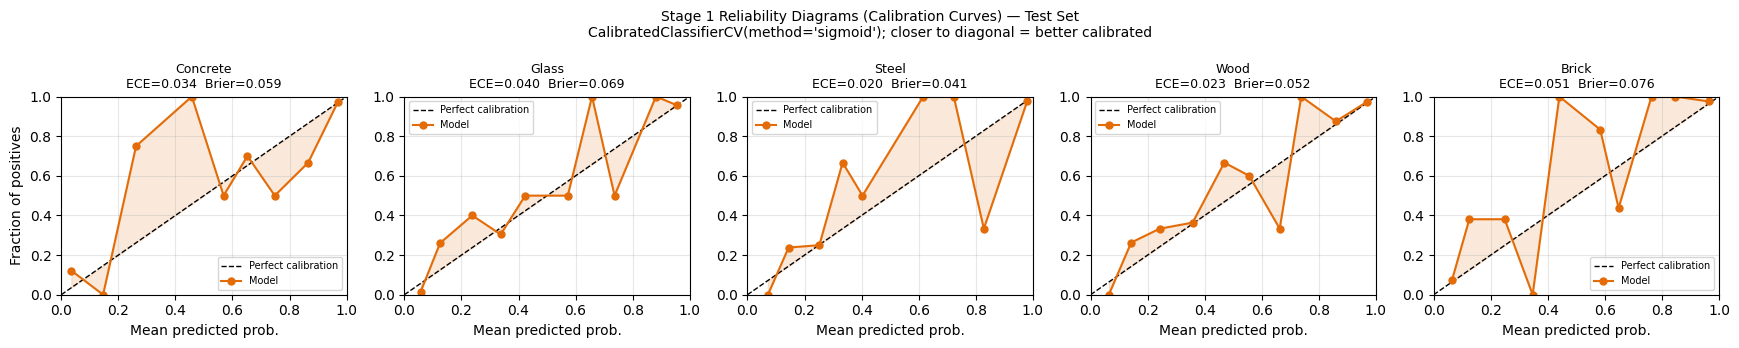


Saved: paper_reliability_diagrams.pdf

ECE (Expected Calibration Error) < 0.05 indicates good calibration.


In [28]:
# ==========================================================
# Paper Validation — Task 4: Stage 1 Reliability Diagrams
#   Calibration curves for all 5 materials showing that
#   CalibratedClassifierCV(method='sigmoid') produces well-
#   calibrated presence probabilities on the test set.
# ==========================================================
from sklearn.calibration import calibration_curve

proba_test = model.stage1.predict_proba(data["X_test_proc"])   # (n_test, M)
y_test_pres_bin = (data["y_test_mask"] & (data["y_test_raw"] > 0)).astype(int)

N_BINS = 10
fig, axes = plt.subplots(1, len(y_cols), figsize=(3.5 * len(y_cols), 3.5))
fig.suptitle(
    "Stage 1 Reliability Diagrams (Calibration Curves) — Test Set\n"
    "CalibratedClassifierCV(method='sigmoid'); closer to diagonal = better calibrated",
    fontsize=10,
)

print(f"{'Material':<12}  {'ECE':>7}  {'MCE':>7}  {'Brier':>8}  {'Verdict':>12}")
print("-" * 54)

for ax, (m, mat) in zip(axes, enumerate(y_cols)):
    p_pred = proba_test[:, m]
    y_true = y_test_pres_bin[:, m].astype(float)

    prob_true, prob_pred = calibration_curve(
        y_true, p_pred, n_bins=N_BINS, strategy="uniform"
    )

    # Expected Calibration Error (ECE) and Max Calibration Error (MCE)
    bins  = np.linspace(0, 1, N_BINS + 1)
    ece_sum = 0.0; mce = 0.0
    n_tot = len(y_true)
    for b in range(N_BINS):
        in_bin = (p_pred >= bins[b]) & (p_pred < bins[b + 1])
        if in_bin.sum() == 0:
            continue
        acc = float(y_true[in_bin].mean())
        conf = float(p_pred[in_bin].mean())
        err = abs(acc - conf)
        ece_sum += in_bin.sum() * err
        mce = max(mce, err)
    ece = ece_sum / n_tot
    brier = float(np.mean((p_pred - y_true) ** 2))

    # Plot
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
    ax.plot(prob_pred, prob_true, "o-", ms=5, lw=1.5, color="#e36c09", label="Model")
    ax.fill_between(prob_pred, prob_pred, prob_true, alpha=0.15, color="#e36c09")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f"{mat}\nECE={ece:.3f}  Brier={brier:.3f}", fontsize=9)
    ax.set_xlabel("Mean predicted prob.")
    if m == 0:
        ax.set_ylabel("Fraction of positives")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    verdict = "well-calibrated" if ece < 0.05 else ("acceptable" if ece < 0.10 else "poor")
    print(f"  {mat:<12}  {ece:>7.4f}  {mce:>7.4f}  {brier:>8.4f}  {verdict:>12}")

plt.tight_layout()
plt.savefig("paper_reliability_diagrams.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: paper_reliability_diagrams.pdf")
print("\nECE (Expected Calibration Error) < 0.05 indicates good calibration.")


In [29]:
# ==========================================================
# Paper Validation — Task 5: 5-Fold Cross-Validation
#   Runs TwoStageConditionalModel over 5 folds of train+val data.
#   Metrics per fold: MAE (p50 on presence rows), CRPS (log-space).
#   Reports mean ± std across folds.
#   NOTE: each fold fits XGBoost, expect ~2–5 min total.
# ==========================================================
from sklearn.model_selection import KFold

# Combine train + val (keep test set untouched)
X_cv_raw  = pd.concat([data["X_train_raw"], data["X_val_raw"]], ignore_index=True)
y_cv_raw  = np.vstack([data["y_train_raw"], data["y_val_raw"]])
y_cv_mask = np.vstack([data["y_train_mask"], data["y_val_mask"]])

N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Storage: per fold, per material
fold_maes  = {mat: [] for mat in y_cols}
fold_crps  = {mat: [] for mat in y_cols}
fold_prese = {mat: [] for mat in y_cols}  # presence freq error

print(f"Running {N_FOLDS}-fold cross-validation on train+val data "
      f"(n={len(X_cv_raw)} rows)...\n")

for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(X_cv_raw)):
    print(f"  Fold {fold_idx + 1}/{N_FOLDS}  (train={len(tr_idx)}, val={len(va_idx)}) ... ", end="", flush=True)

    X_tr_raw = X_cv_raw.iloc[tr_idx].reset_index(drop=True)
    X_va_raw = X_cv_raw.iloc[va_idx].reset_index(drop=True)
    y_tr_raw = y_cv_raw[tr_idx]
    y_va_raw = y_cv_raw[va_idx]
    y_tr_msk = y_cv_mask[tr_idx]
    y_va_msk = y_cv_mask[va_idx]

    # Refit preprocessor on training fold only
    fold_pre = ColumnTransformer(transformers=[
        ("num", StandardScaler(), ["Construction period"]),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         ["Typology", "Primary Code", "Hybrid Structure", "Country"]),
    ])
    X_tr_proc = fold_pre.fit_transform(X_tr_raw)
    X_va_proc = fold_pre.transform(X_va_raw)

    # Fit model (no calibrate_sampling for speed; core metrics are Stage 2)
    fold_model = TwoStageConditionalModel(random_state=SEED)
    import io, contextlib, warnings
    with contextlib.redirect_stdout(io.StringIO()), warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fold_model.fit(X_tr_proc, X_tr_raw, y_tr_raw, y_tr_msk)

    # ── MAE and CRPS per material on validation fold ──────────────────────
    for m, mat in enumerate(y_cols):
        va_pres = y_va_msk[:, m] & (y_va_raw[:, m] > 0)
        if va_pres.sum() < 3:
            continue

        qxgb = fold_model.stage2.models_.get(mat)
        if qxgb is None:
            continue

        y_true = y_va_raw[va_pres, m]
        y_log  = np.log(y_true + LOG_EPS)
        pq     = qxgb.predict_q_log(X_va_proc[va_pres])    # (n, 3)
        p50    = pq[:, 1]

        mae  = float(np.mean(np.abs(y_true - (np.exp(p50) - LOG_EPS))))
        crps = qxgb.crps_gaussian(X_va_proc[va_pres], y_log)
        fold_maes[mat].append(mae)
        fold_crps[mat].append(crps)

    # ── Presence frequency error (Stage 1) ───────────────────────────────
    g_va = build_group_keys(X_va_raw)
    pres_samp = fold_model.stage1.sample_presence(
        X_va_proc, n_samples=200, temperature=2.5,
        random_state=SEED, primary_codes=g_va,
    )
    samp_freq = pres_samp.mean(axis=1)   # (n_val, M)
    true_freq_fold = (y_va_msk & (y_va_raw > 0)).astype(float)
    for m, mat in enumerate(y_cols):
        err = float(np.abs(samp_freq[:, m].mean() - true_freq_fold[:, m].mean()))
        fold_prese[mat].append(err)

    print(f"done")

# ── Summary table ─────────────────────────────────────────────────────────
print(f"\n{'Material':<12}  {'MAE mean':>10}  {'MAE std':>9}  "
      f"{'CRPS mean':>10}  {'CRPS std':>9}  {'Pres |err|':>10}")
print("-" * 68)

cv_summary = []
for mat in y_cols:
    maes = fold_maes[mat]
    crps = fold_crps[mat]
    pres = fold_prese[mat]
    if not maes:
        print(f"  {mat:<12}  {'—':>10}")
        continue
    mae_m  = float(np.mean(maes));  mae_s  = float(np.std(maes))
    crps_m = float(np.mean(crps));  crps_s = float(np.std(crps))
    pres_m = float(np.mean(pres))
    cv_summary.append(dict(
        Material=mat,
        MAE_mean=round(mae_m, 2), MAE_std=round(mae_s, 2),
        CRPS_mean=round(crps_m, 4), CRPS_std=round(crps_s, 4),
        Pres_err=round(pres_m, 3),
    ))
    print(f"  {mat:<12}  {mae_m:>10.2f}  {mae_s:>9.2f}  "
          f"{crps_m:>10.4f}  {crps_s:>9.4f}  {pres_m:>10.3f}")

print()
cv_df = pd.DataFrame(cv_summary)
print("All figures in kg/m² (MAE) or log-kg/m² (CRPS).")
print("Pres |err| = |sampled presence freq − true freq|.")


Running 5-fold cross-validation on train+val data (n=2184 rows)...

  Fold 1/5  (train=1747, val=437) ... done
  Fold 2/5  (train=1747, val=437) ... done
  Fold 3/5  (train=1747, val=437) ... done
  Fold 4/5  (train=1747, val=437) ... done
  Fold 5/5  (train=1748, val=436) ... done

Material        MAE mean    MAE std   CRPS mean   CRPS std  Pres |err|
--------------------------------------------------------------------
  Concrete          445.88      21.74      0.3196     0.0245       0.069
  Glass               1.19       0.07      0.2969     0.0193       0.034
  Steel              22.02       1.60      0.3805     0.0158       0.100
  Wood               10.21       1.04      0.5183     0.0297       0.097
  Brick             213.21       2.92      0.4178     0.0536       0.066

All figures in kg/m² (MAE) or log-kg/m² (CRPS).
Pres |err| = |sampled presence freq − true freq|.
